
# GTZAN Music Genre Classification 🎵

**Goal**: Classify 10 music genres (GTZAN) from audio, using deep learning in Keras/TensorFlow.

**GitHub:** https://github.com/sean-coffey/5511_final_project

## Setup & Environment

In [50]:
# Reuqired imports
import os
import sys
from pathlib import Path
import math
import time
from datetime import datetime
import random
import shutil
from pathlib import Path
from PIL import Image
import warnings

import json
import numpy as np
import pandas as pd
# libraries for sound analysis
import librosa
import librosa.display
import soundfile as sf

# charts
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting defaults
sns.set_theme(
    context="notebook",
    style="darkgrid",
    palette="deep"
)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10
})

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans  # Used in EDA to understand the dataset distribution
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, precision_recall_fscore_support
)

# Using sklearn library for feature only model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC

import kagglehub
import platform

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# Mixed precision (recommended on T4 on Kaggle and also MacBook Pro M1)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("float32")

# Having got it all working, let's only see errors not warnings
WARNING_LEVEL = 2
os.environ['TF_CPP_MIN_LOG_LEVEL'] = str(WARNING_LEVEL)  # 0=all, 1=no INFO, 2=no INFO+WARNING, 3=no INFO+WARNING+ERROR
print(f"Note Tensorflow warning level set to {str(WARNING_LEVEL)}: 0=all, 1=no INFO, 2=no INFO+WARNING, 3=no INFO+WARNING+ERROR")

AUTOTUNE = tf.data.AUTOTUNE
SEED = 42
rng = np.random.default_rng(SEED)
tf.random.set_seed(SEED)

# Paths: Kaggle dataset path vs local fallback
KAGGLE_GTZAN = Path('/kaggle/input/gtzan-dataset-music-genre-classification')
LOCAL_GTZAN = Path('gtzan')

if KAGGLE_GTZAN.exists():
    DATA_DIR = KAGGLE_GTZAN
else:
    DATA_DIR = LOCAL_GTZAN

AUDIO_DIR = DATA_DIR / 'Data' / 'genres_original'
IMAGES_DIR = DATA_DIR / 'Data' / 'images_original'
print("Using path for audio:", AUDIO_DIR)
print("Using path for images:", IMAGES_DIR)

OUTPUT_DIR = Path("./outputs/5511_final_project")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Set up for Apple Silicon GPU acceleration - locally I run a MacBook Pro M1
is_macos = platform.system() == "Darwin"
if is_macos:
    print(f"Running on macOS: {is_macos}")
    # Enable GPU acceleration if available

    print("Metal GPU Available: ", len(tf.config.list_physical_devices('GPU')) > 0)
    if tf.config.list_physical_devices('GPU'):
        print("Using GPU acceleration with Metal")
        for gpu in tf.config.list_physical_devices('GPU'):
            tf.config.experimental.set_memory_growth(gpu, True)
    else:
        print("GPU not available, using CPU")

# helper function to save figures
def save_figure(name=None, dpi=300, bbox_inches='tight', pad_inches=0.1):
    # Create directory if it doesn't exist
    save_dir = "figs/5511_final_project"
    os.makedirs(save_dir, exist_ok=True)
    # Generate filename
    if name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"chart_{timestamp}.png"
    else:
        # Clean the name to be filename-safe
        filename = "".join(c for c in name if c.isalnum() or c in (' ', '-', '_')).rstrip()
        filename = filename.replace(' ', '_')
        if not filename.endswith('.png'):
            filename += '.png'
    # Full path
    filepath = os.path.join(save_dir, filename)
    # Save the figure
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
    print(f"Figure saved: {filepath}")
    return filepath

Python: 3.11.13 (main, Jun  3 2025, 18:38:25) [Clang 17.0.0 (clang-1700.0.13.3)]
TensorFlow: 2.20.0
GPU devices: []
Note Tensorflow warning level set to 2: 0=all, 1=no INFO, 2=no INFO+WARNING, 3=no INFO+WARNING+ERROR
Using path for audio: gtzan/Data/genres_original
Using path for images: gtzan/Data/images_original
Running on macOS: True
Metal GPU Available:  False
GPU not available, using CPU


In [51]:
# Load data using kagglehub if not already available locally
def setup_project_data():
    cache_path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
    dataset_dir = Path("gtzan")
    if not dataset_dir.exists():
        shutil.copytree(cache_path, dataset_dir)
        print(f"Dataset copied to: {dataset_dir}")
    else:
        print(f"Dataset already exists at: {dataset_dir}")
    return dataset_dir

dataset_path = setup_project_data()

Dataset already exists at: gtzan


## 1. Dataset Overview & EDA
DTZAN has been called the MNIST of music, and it is a collection of 10 genres with 100 audio files each, all having a length of 30 seconds.
The dataset is split into 3 parts:
1) genres original - A collection of 10 genres with 100 audio files each, all having a length of 30 seconds.
2) images original - A visual representation for each audio file. The audio files were converted to Mel Spectrograms to make this possible.
3) Two CSV files - Containing features of the audio files. One file has for each song (30 seconds long) a mean and variance computed over multiple features that can be extracted from an audio file. The other file has the same structure, but the songs were split before into 3 seconds audio files thus giving ten times the samples to feed into modelling. IMPORTANT NOTE: When running train-test split etc, need to make sure that we split at the track level not the sample level, otherwise there is likelihood that the same track will leak into both splits.

### What is a Mel Spectrogram
 A spectrogram is a time–frequency representation of a signal: you break the signal into short overlapping windows (frames) and compute a Fourier transform (or short-time Fourier transform, STFT) on each frame, giving you the magnitude (or power) spectrum per time-step. The result is a 2D representation:_time_on one axis,_frequency_on the other, and_amplitude / power_ as the value (often shown via color or intensity). ([Wikipedia](https://en.wikipedia.org/wiki/Spectrogram?utm_source=chatgpt.com "Spectrogram"))
- A **Mel spectrogram**(sometimes “mel-scaled spectrogram”) transforms the frequency axis into the **mel scale**, which is a perceptual scale intended to approximate how humans perceive pitch differences: human hearing is more sensitive (more discriminative) at lower frequencies than at very high frequencies. Thus the mel scale compresses high-frequency bands relative to low frequencies. ([Hugging Face](https://huggingface.co/learn/audio-course/en/chapter1/audio_data?utm_source=chatgpt.com "Introduction to audio data"))
- Technically, you still compute an STFT (or equivalent) first, get a power spectrogram, and then apply a **filter bank**(often triangular filters) to sum / aggregate (or weigh) the linear-frequency bins into `n_mels`mel-frequency bins.
- Then (often) you convert to decibels (log scale) to get a **log-mel spectrogram**. In this dataset, it looks like we have log-mel spectrograms.

### EDA Approach
1) Import csv files as pd dataframes to get an idea of the feature contents.
2) Check basic stats of audios and images (number of files, distribution of labels, genre names)
3) Display a few visualizations of audio and image files (this is just to get a feel for the data)
4) List out what the features actually are. (enlisted help of AI to search for definitions of the features)
4) Inspect the feature information in more detail to look for the features that may help us most in classification. (Heatmap to show genre vs dataset average on normalised features, pca analysis to look at how the genres cluster and separate, Fisher analysis to find the features that have most discriminative power and then Box-plots to look at distributions of most discriminative features.)
5) Principal Component Analysis - do the genres naturally cluster?

### 1) Import csv files as pd dataframes to get an idea of the feature contents.

In [52]:
features_30_sec = pd.read_csv('gtzan/Data/features_30_sec.csv', sep = ',')
features_30_sec

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,rock.00095.wav,661794,0.352063,0.080487,0.079486,0.000345,2008.149458,282174.689224,2106.541053,88609.749506,...,45.050526,-13.289984,41.754955,2.484145,36.778877,-6.713265,54.866825,-1.193787,49.950665,rock
996,rock.00096.wav,661794,0.398687,0.075086,0.076458,0.000588,2006.843354,182114.709510,2068.942009,82426.016726,...,33.851742,-10.848309,39.395096,1.881229,32.010040,-7.461491,39.196327,-2.795338,31.773624,rock
997,rock.00097.wav,661794,0.432142,0.075268,0.081651,0.000322,2077.526598,231657.968040,1927.293153,74717.124394,...,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515,rock
998,rock.00098.wav,661794,0.362485,0.091506,0.083860,0.001211,1398.699344,240318.731073,1818.450280,109090.207161,...,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088,rock


In [53]:
features_3_sec = pd.read_csv('gtzan/Data/features_3_sec.csv', sep = ',')
features_3_sec

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,rock.00099.5.wav,66149,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,rock
9986,rock.00099.6.wav,66149,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,rock
9987,rock.00099.7.wav,66149,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,rock
9988,rock.00099.8.wav,66149,0.387527,0.084815,0.066430,0.000320,2084.515327,203891.039161,2018.366254,22860.992562,...,28.323744,-5.363541,17.209942,6.462601,21.442928,2.354765,24.843613,0.675824,12.787750,rock


### 2) Check basic stats of audios and images (number of files, distribution of labels, genre names)

In [54]:
def analyze_audio_image_files(audio_dir, images_dir):
    """
    Compare audio and image files by genre and identify missing files
    """
    print("ANALYZING AUDIO vs IMAGE FILES BY GENRE")
    print("=" * 50)

    # Get genres from both directories
    genres_audio = sorted([d.name for d in audio_dir.iterdir() if d.is_dir()])
    genres_images = sorted([d.name for d in images_dir.iterdir() if d.is_dir()])

    print(f"Audio genres: {genres_audio}")
    print(f"Image genres: {genres_images}")

    if genres_audio != genres_images:
        print("WARNING: Genres don't match between directories!")
        return
    else:
        print("Genres match between directories\n")

    # Collect files
    audio_files = []
    image_files = []

    for genre in genres_audio:
        # Audio files
        audio_genre_files = list((audio_dir / genre).glob("*.wav"))
        for f in audio_genre_files:
            audio_files.append({
                "genre": genre,
                "filename": f.name,
                "path": str(f)
            })
        # Image files
        image_genre_files = list((images_dir / genre).glob("*.png"))
        for f in image_genre_files:
            image_files.append({
                "genre": genre,
                "filename": f.name,
                "path": str(f)
            })

    # Create DataFrames
    audio_df = pd.DataFrame(audio_files)
    images_df = pd.DataFrame(image_files)

    print(f"Total audio files: {len(audio_df)}")
    print(f"Total image files: {len(images_df)}")

    # Count by genre
    audio_counts = audio_df['genre'].value_counts().sort_index()
    images_counts = images_df['genre'].value_counts().sort_index()

    print(f"{'Genre':<12} {'Audio':<8} {'Images':<8} {'Difference':<12}")
    print("-" * 45)

    all_genres = sorted(set(audio_counts.index) | set(images_counts.index))
    missing_images = []

    for genre in all_genres:
        audio_count = audio_counts.get(genre, 0)
        images_count = images_counts.get(genre, 0)
        difference = audio_count - images_count

        status = ""
        if difference > 0:
            status = f"{difference} missing"
            missing_images.append((genre, difference))
        elif difference < 0:
            status = f"{-difference} extra"
        else:
            status = "Match"
        print(f"{genre:<12} {audio_count:<8} {images_count:<8} {status:<12}")

    if missing_images:
        for genre, missing_count in missing_images:
            print(f"\n {genre.upper()} (missing {missing_count} images):")

            # Get audio filenames for this genre
            genre_audio_files = set(audio_df[audio_df['genre'] == genre]['filename'])
            genre_image_files = set(
                images_df[images_df['genre'] == genre]['filename'] if genre in images_counts.index else [])

            # Convert image filenames to expected audio format for comparison
            # Image format is like "blues00001.png" -> "blues.00001.wav"
            expected_audio_names = set()
            for img_name in genre_image_files:
                # Convert blues00001.png -> blues.00001.wav
                stem = img_name.replace('.png', '')
                if len(stem) >= 5:  # e.g., blues00001
                    audio_name = f"{genre}.{stem[len(genre):].zfill(5)}.wav"
                    expected_audio_names.add(audio_name)

            # Find which audio files don't have corresponding images
            missing_image_files = genre_audio_files - expected_audio_names

            if missing_image_files:
                for missing_file in sorted(missing_image_files):
                    expected_img = missing_file.replace('.wav', '.png').replace('.', '')
                    print(f"      {missing_file} -> should have {expected_img}")

    # Return the DataFrames for further analysis
    return audio_df, images_df, audio_counts, images_counts

audio_df, images_df, audio_counts, images_counts = analyze_audio_image_files(AUDIO_DIR, IMAGES_DIR)

ANALYZING AUDIO vs IMAGE FILES BY GENRE
Audio genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Image genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Genres match between directories

Total audio files: 1000
Total image files: 999
Genre        Audio    Images   Difference  
---------------------------------------------
blues        100      100      Match       
classical    100      100      Match       
country      100      100      Match       
disco        100      100      Match       
hiphop       100      100      Match       
jazz         100      99       1 missing   
metal        100      100      Match       
pop          100      100      Match       
reggae       100      100      Match       
rock         100      100      Match       

 JAZZ (missing 1 images):
      jazz.00054.wav -> should have jazz00054png


### 3) Display a few visualizations of audio and image files

Figure saved: figs/5511_final_project/visualize_random_samples.png


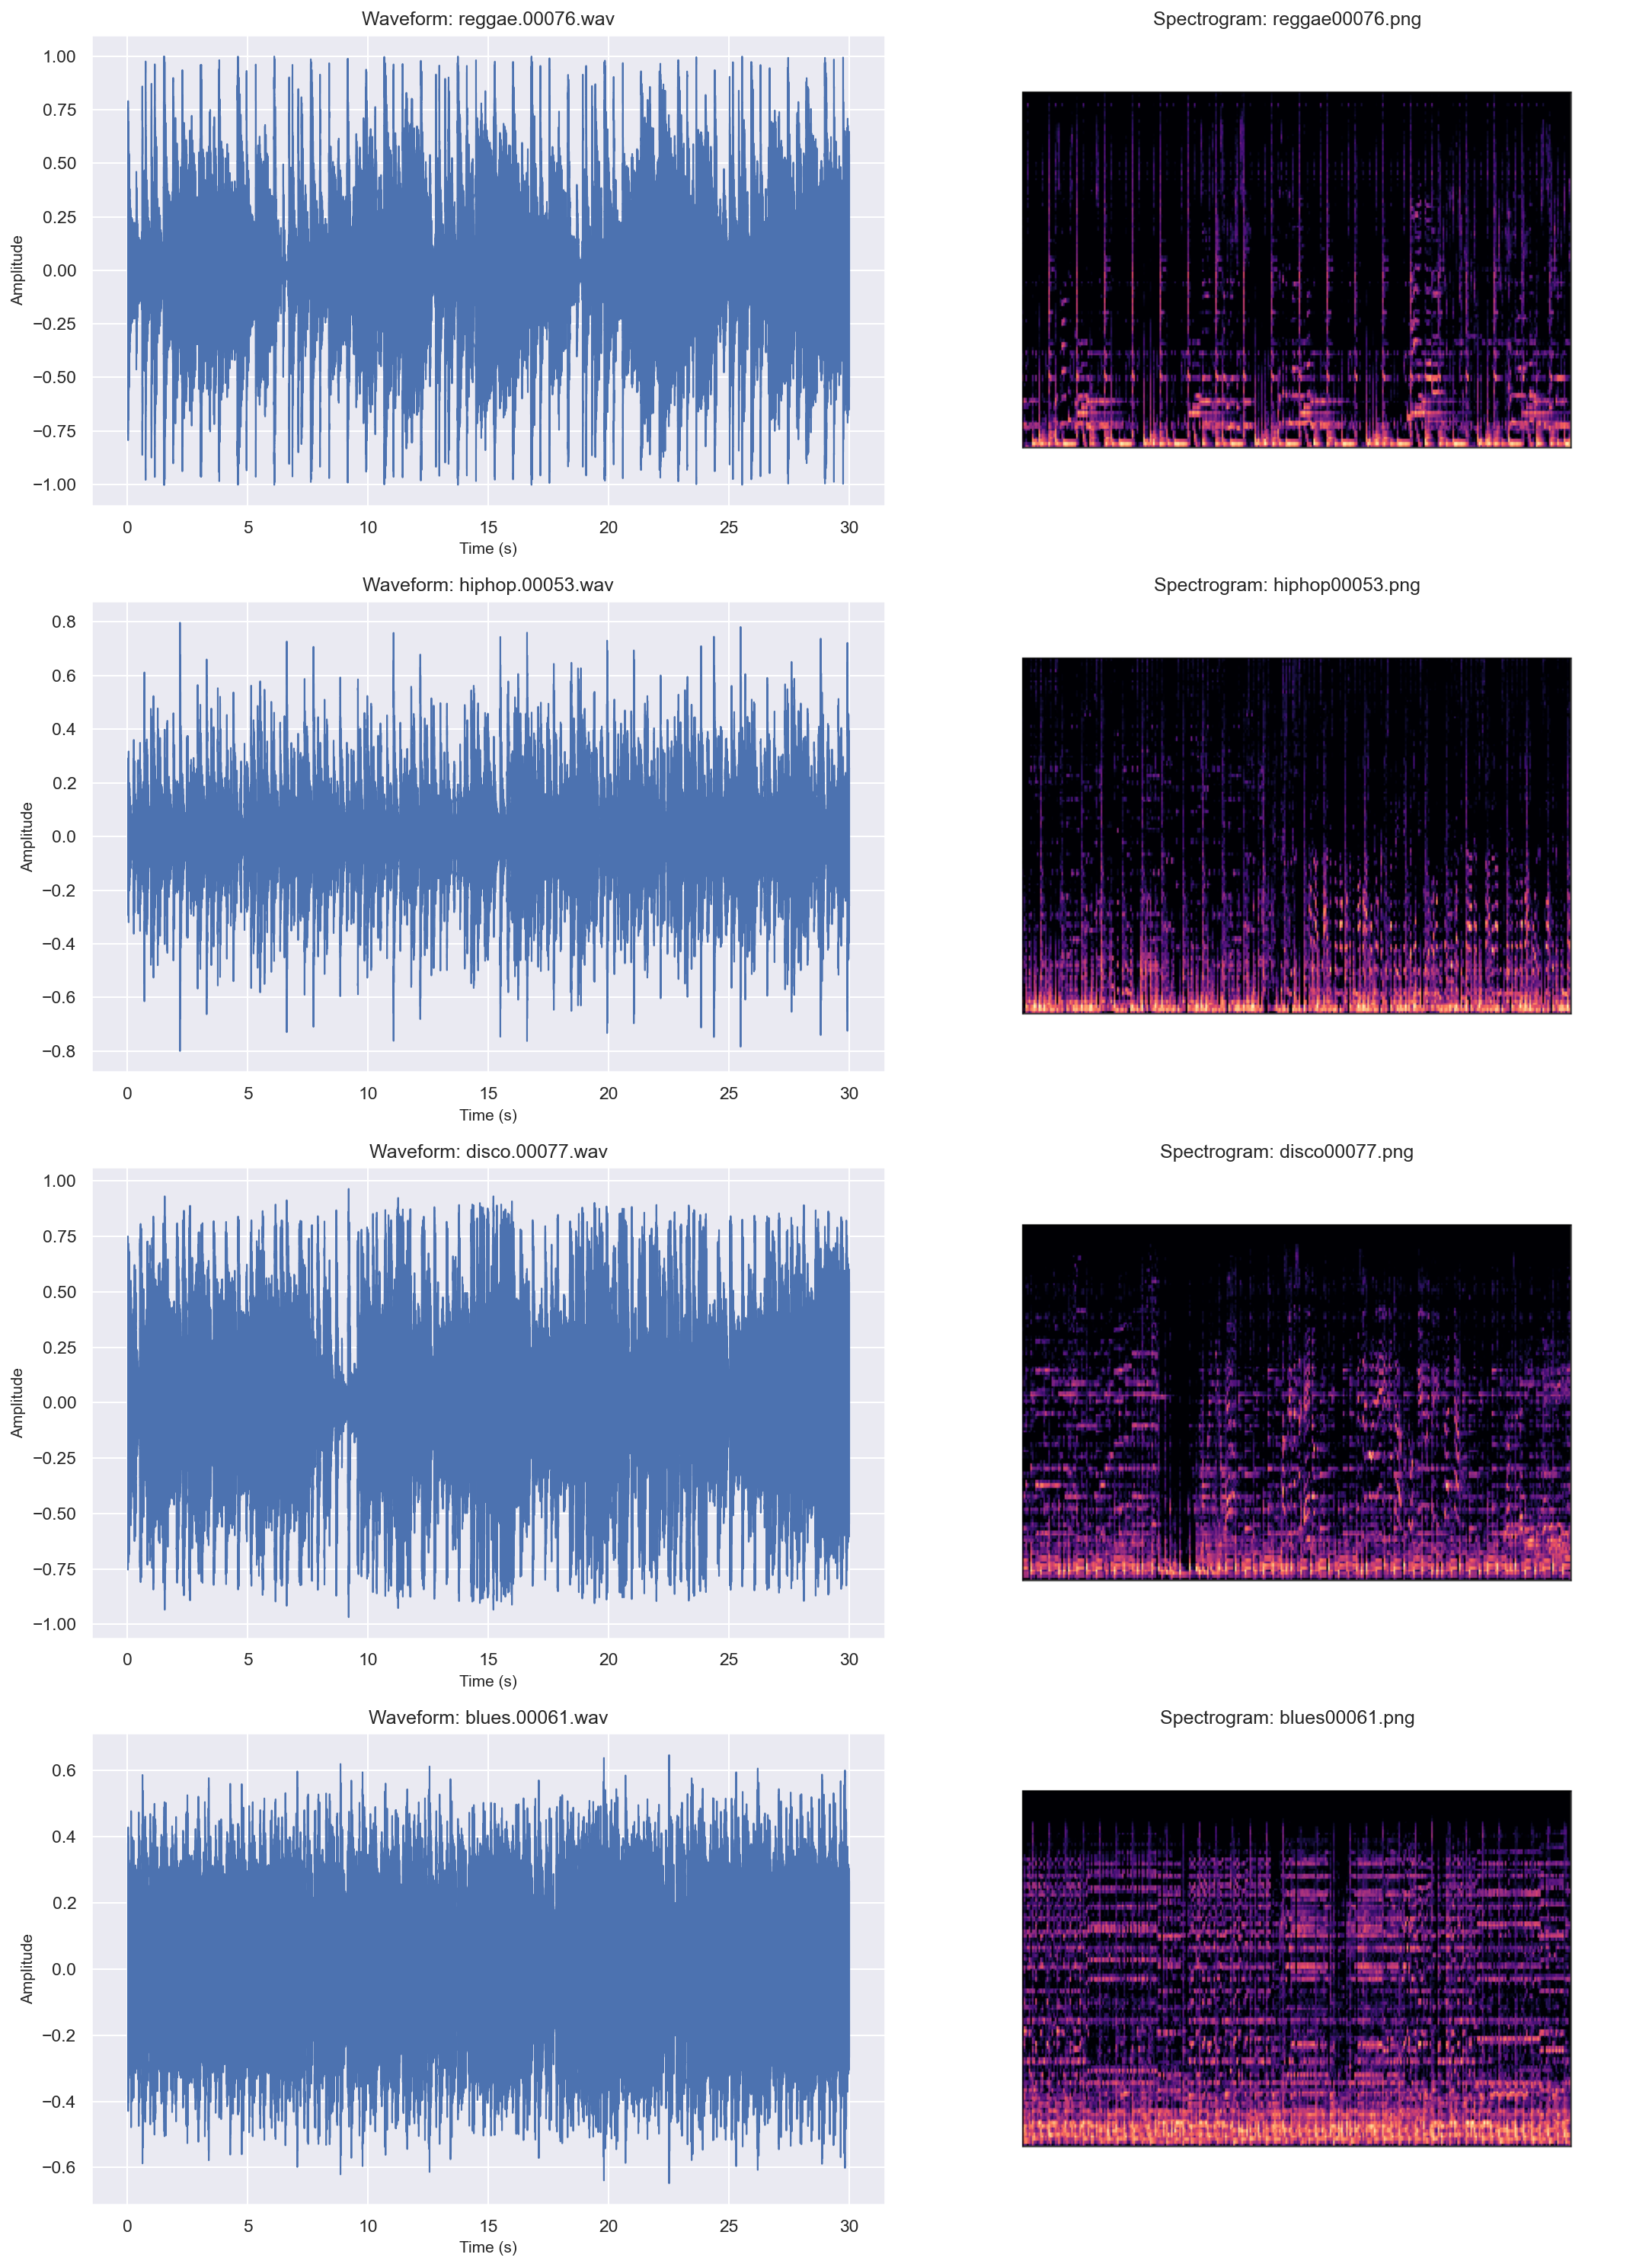

In [55]:
def visualize_random_samples(features_df, n_samples=4):
    """
    Picks 4 rows at random from features_30_sec, each with a different label,
    and creates a 4x2 grid showing:
    - Column 1: Waveform based on filename from genres_original directory
    - Column 2: Spectrogram from images_original directory
    """

    # Get unique labels and sample one row from each
    unique_labels = features_df['label'].unique()

    # Randomly select n_samples labels
    selected_labels = np.random.choice(unique_labels, size=min(n_samples, len(unique_labels)), replace=False)

    # Sample one row from each selected label
    sampled_rows = []
    for label in selected_labels:
        label_rows = features_df[features_df['label'] == label]
        sampled_row = label_rows.sample(1, random_state=np.random.randint(0, 10000)).iloc[0]
        sampled_rows.append(sampled_row)

    # Create the figure
    fig, axes = plt.subplots(n_samples, 2, figsize=(15, 5 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i, row in enumerate(sampled_rows):
        filename = row['filename']
        label = row['label']

        # Column 1: Waveform
        ax_wave = axes[i, 0]
        audio_path = AUDIO_DIR / label / filename

        try:
            if audio_path.exists():
                y, sr = librosa.load(str(audio_path), sr=22050, duration=30.0)
                librosa.display.waveshow(y, sr=sr, ax=ax_wave)
                ax_wave.set_title(f'Waveform: {filename}')
                ax_wave.set_xlabel('Time (s)')
                ax_wave.set_ylabel('Amplitude')
            else:
                ax_wave.text(0.5, 0.5, f'Audio file not found:\n{audio_path}',
                             ha='center', va='center', transform=ax_wave.transAxes)
                ax_wave.set_title('Waveform: File Not Found')
        except Exception as e:
            ax_wave.text(0.5, 0.5, f'Error loading audio:\n{str(e)}',
                         ha='center', va='center', transform=ax_wave.transAxes)
            ax_wave.set_title('Waveform: Error')

        # Column 2: Spectrogram
        ax_spec = axes[i, 1]

        # Transform filename: remove dots and replace .wav with .png
        spec_filename = filename.replace('.', '').replace('wav', '.png')
        spec_path = IMAGES_DIR / label / spec_filename

        try:
            if spec_path.exists():
                img = Image.open(spec_path)
                ax_spec.imshow(img)
                ax_spec.set_title(f'Spectrogram: {spec_filename}')
                ax_spec.axis('off')
            else:
                ax_spec.text(0.5, 0.5, f'Spectrogram not found:\n{spec_path}',
                             ha='center', va='center', transform=ax_spec.transAxes)
                ax_spec.set_title('Spectrogram: File Not Found')
        except Exception as e:
            ax_spec.text(0.5, 0.5, f'Error loading spectrogram:\n{str(e)}',
                         ha='center', va='center', transform=ax_spec.transAxes)
            ax_spec.set_title('Spectrogram: Error')

    plt.tight_layout()
    save_figure('visualize_random_samples')
    plt.show()

    return sampled_rows

sampled_data = visualize_random_samples(features_30_sec)

In [56]:
# Sample file to check size and channels:
img_path = Path("gtzan/Data/images_original/blues/blues00043.png")

if img_path.exists():
    # Load image with PIL
    img_pil = Image.open(img_path)

    print("PIL Image Info:")
    print(f"  Size (W x H): {img_pil.size}")
    print(f"  Mode: {img_pil.mode}")
    print(f"  Format: {img_pil.format}")

    # Convert to numpy array to check channels
    img_array = np.array(img_pil)
    print(f"\nNumPy Array Info:")
    print(f"  Shape: {img_array.shape}")
    print(f"  Data type: {img_array.dtype}")
    print(f"  Min value: {img_array.min()}")
    print(f"  Max value: {img_array.max()}")

    # Determine channels
    if len(img_array.shape) == 2:
        print(f"  Channels: 1 (Grayscale)")
    elif len(img_array.shape) == 3:
        print(f"  Channels: {img_array.shape[2]}")
        if img_array.shape[2] == 1:
            print("    → Grayscale with explicit channel dimension")
        elif img_array.shape[2] == 3:
            print("    → RGB")
        elif img_array.shape[2] == 4:
            print("    → RGBA")

    # Show shapoe for pre-processing
    if len(img_array.shape) == 2:
        h, w = img_array.shape
        c = 1
        print(f"\nFor your template:")
        print(f"  Height: {h}")
        print(f"  Width: {w}")
        print(f"  Channels: {c}")
        print(f"  Shape for CNN: ({h}, {w}, {c})")
    elif len(img_array.shape) == 3:
        h, w, c = img_array.shape
        print(f"\nFor your template:")
        print(f"  Height: {h}")
        print(f"  Width: {w}")
        print(f"  Channels: {c}")
        print(f"  Shape for CNN: ({h}, {w}, {c})")

else:
    print("Image file not found!")

PIL Image Info:
  Size (W x H): (432, 288)
  Mode: RGBA
  Format: PNG

NumPy Array Info:
  Shape: (288, 432, 4)
  Data type: uint8
  Min value: 0
  Max value: 255
  Channels: 4
    → RGBA

For your template:
  Height: 288
  Width: 432
  Channels: 4
  Shape for CNN: (288, 432, 4)


### 4) List out feature definitions and ranges in dataset (AI Search to help my understanding of what the features represent)

**🎵 Spectral Features (Frequency-based)**

**`spectral_centroid_mean`** - The "brightness" of the sound
- Where most of the energy is concentrated in the frequency spectrum
- High values = bright, treble-heavy sound (like cymbals)
- Low values = dark, bass-heavy sound (like bass guitar)

**`spectral_centroid_var`** - How much the brightness varies
- High variance = brightness changes a lot throughout the song
- Low variance = consistent brightness level

**`spectral_bandwidth_mean`** - The "width" of the sound
- How spread out the frequencies are around the spectral centroid
- High bandwidth = rich, complex sound with many frequencies
- Low bandwidth = pure, simple sound (like a whistle)

**`rolloff_mean`** - The frequency cutoff point
- The frequency below which 85% of the signal's energy lies
- Higher rolloff = more high-frequency content
- Lower rolloff = mostly low-frequency content

**🎼 Harmonic Features**

**`chroma_stft_mean`** - Musical note content
- Represents the 12 different pitch classes (C, C#, D, etc.)
- Captures the harmonic and melodic characteristics
- Useful for identifying key signatures and chord progressions

**🔊 Energy Features**

**`rms_mean`** - Average loudness/energy
- Root Mean Square of the audio signal
- Higher RMS = louder, more energetic music
- Lower RMS = quieter, softer music

**🎛️ Timbre Features (MFCCs)**

**`mfcc1_mean`, `mfcc2_mean`, `mfcc4_mean`** - Spectral shape characteristics
- **MFCC** = Mel-Frequency Cepstral Coefficients
- Capture the overall shape of the frequency spectrum
- **MFCC1**: Usually related to overall spectral shape/energy
- **MFCC2-4**: Capture more detailed spectral characteristics
- These help distinguish between different instruments and vocal timbres

**🎚️ Perceptual Features**

**`perceptr_var`** - Variation in perceptual qualities
- Related to psychoacoustic properties (how humans perceive sound)
- High variance = more dynamic perceptual changes
- Low variance = more consistent perceptual qualities

**🎸 Genre Applications**

These features help distinguish genres because:
- **Classical**: High chroma (complex harmonies), moderate spectral centroid
- **Metal**: High RMS (loud), high spectral centroid (bright/harsh)
- **Blues**: Distinctive MFCC patterns, moderate bandwidth
- **Jazz**: High chroma variance (complex chord changes)
- **Hip-hop**: Distinctive MFCC patterns (vocal content), specific spectral characteristics

Each feature captures a different aspect of how music "sounds," making them powerful for automatic genre classification!


### 5) Analyze features in more detail with charts (Feature vs Genre Heatmap, Fisher Analysis, BoxPlots)

Figure saved: figs/5511_final_project/normalized_feature_heatmap.png


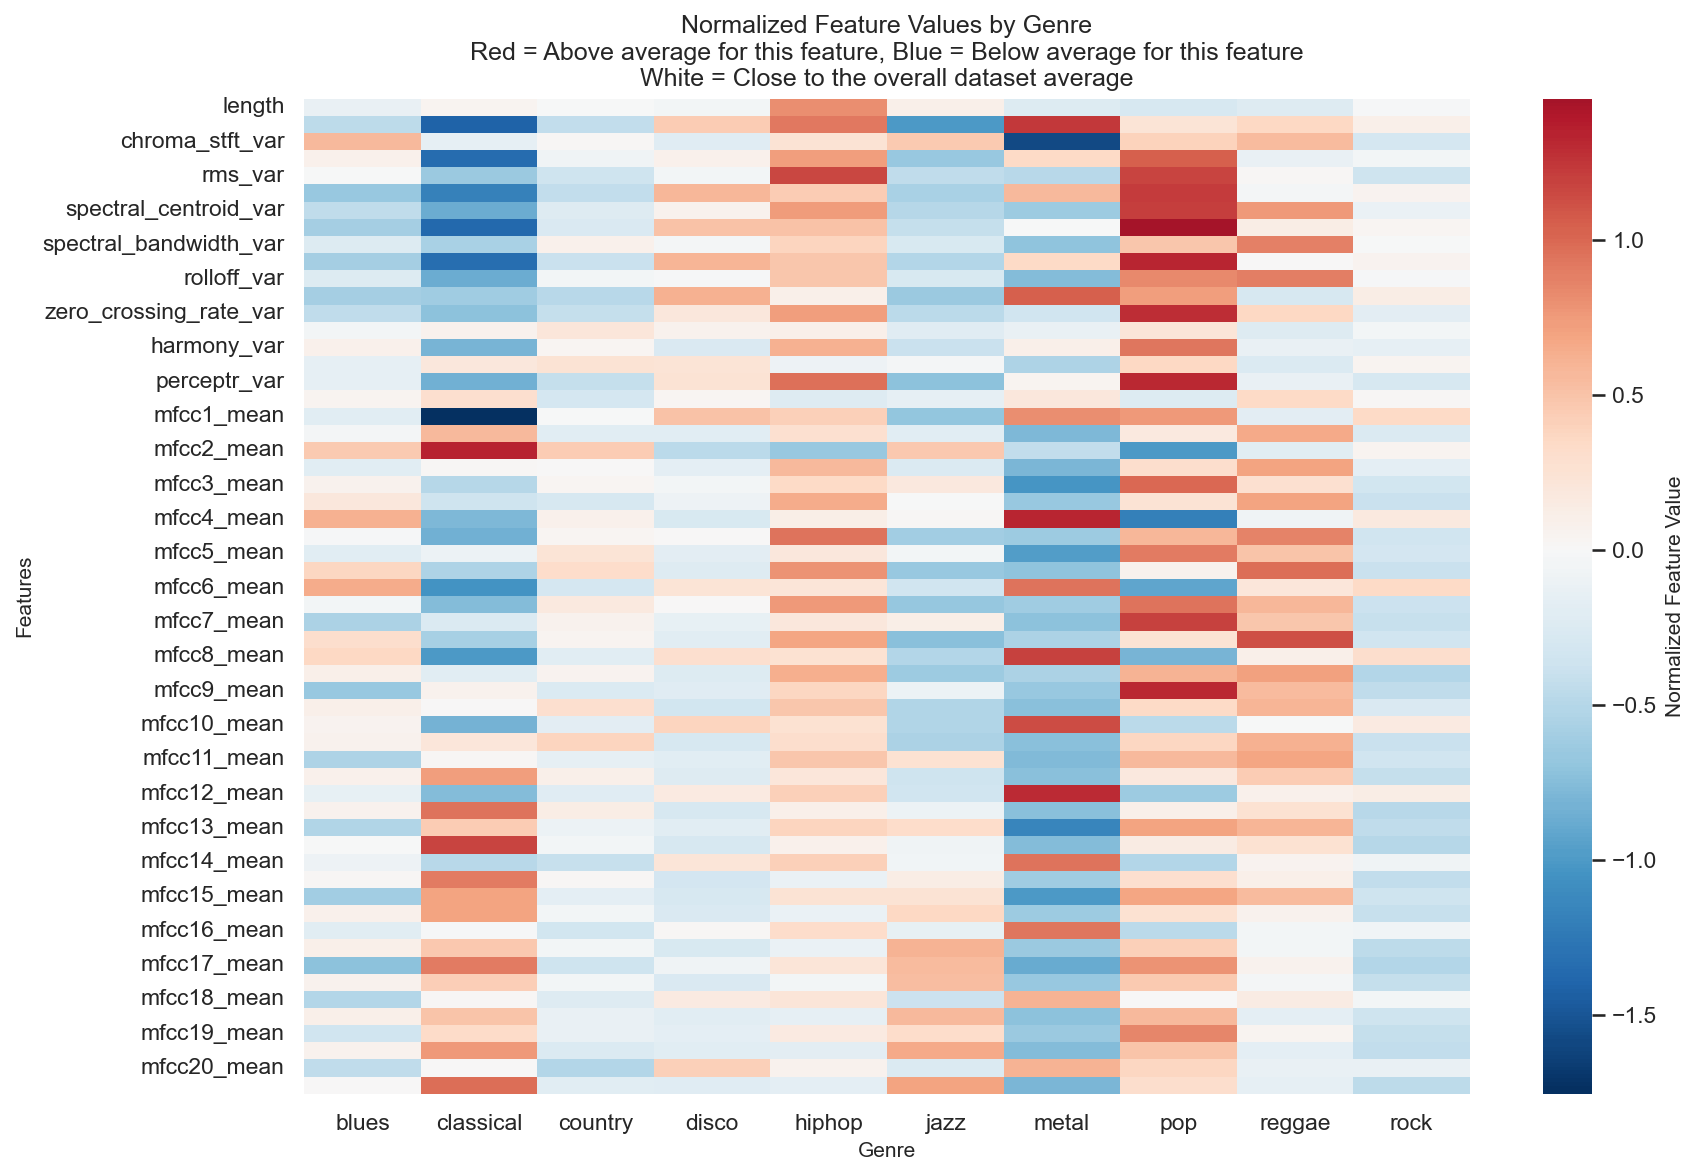

Figure saved: figs/5511_final_project/feature_discrimination_power.png


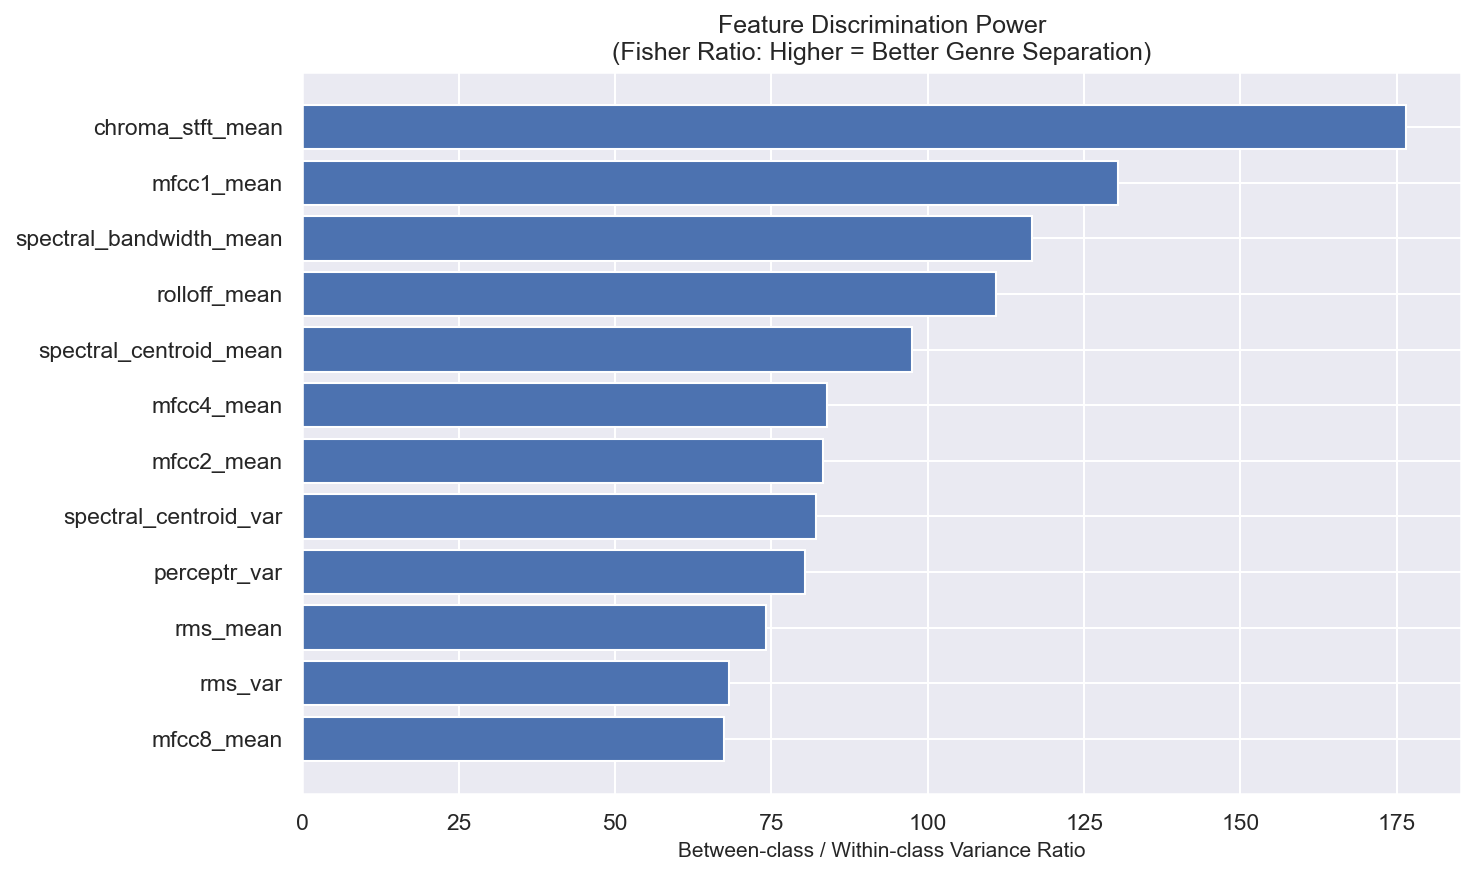

Figure saved: figs/5511_final_project/genre_box_plots.png


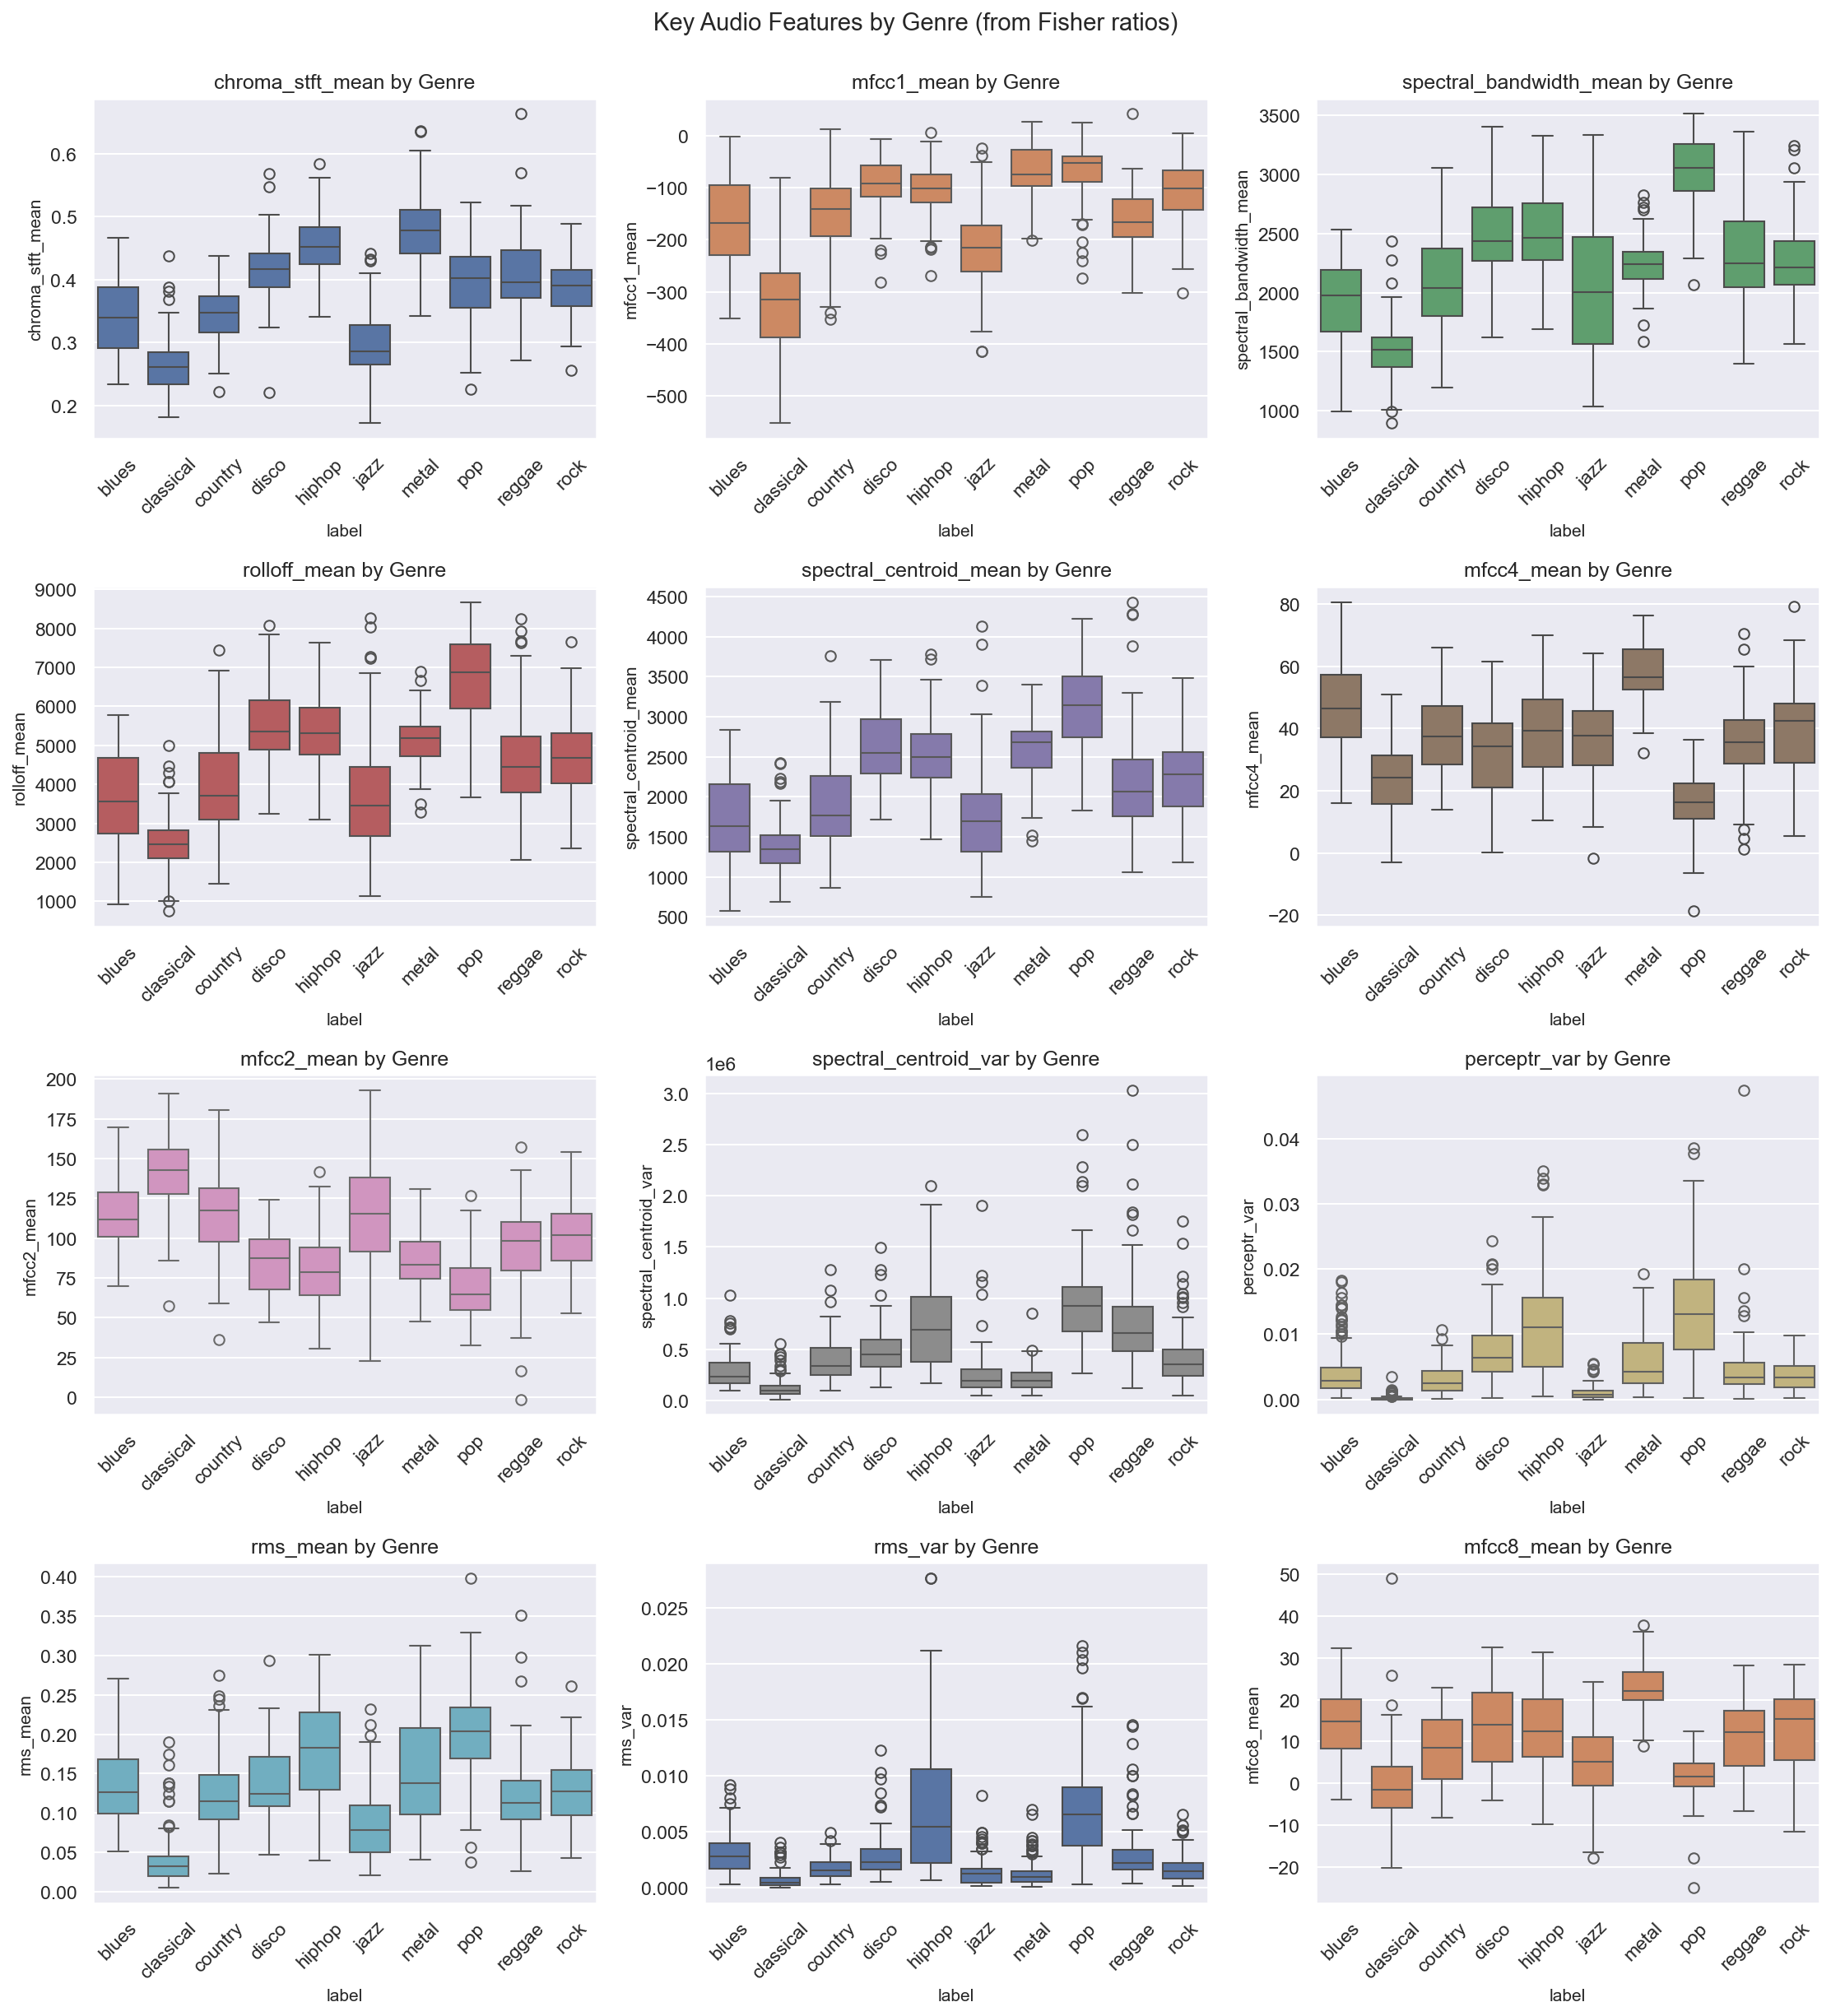

Figure saved: figs/5511_final_project/.png


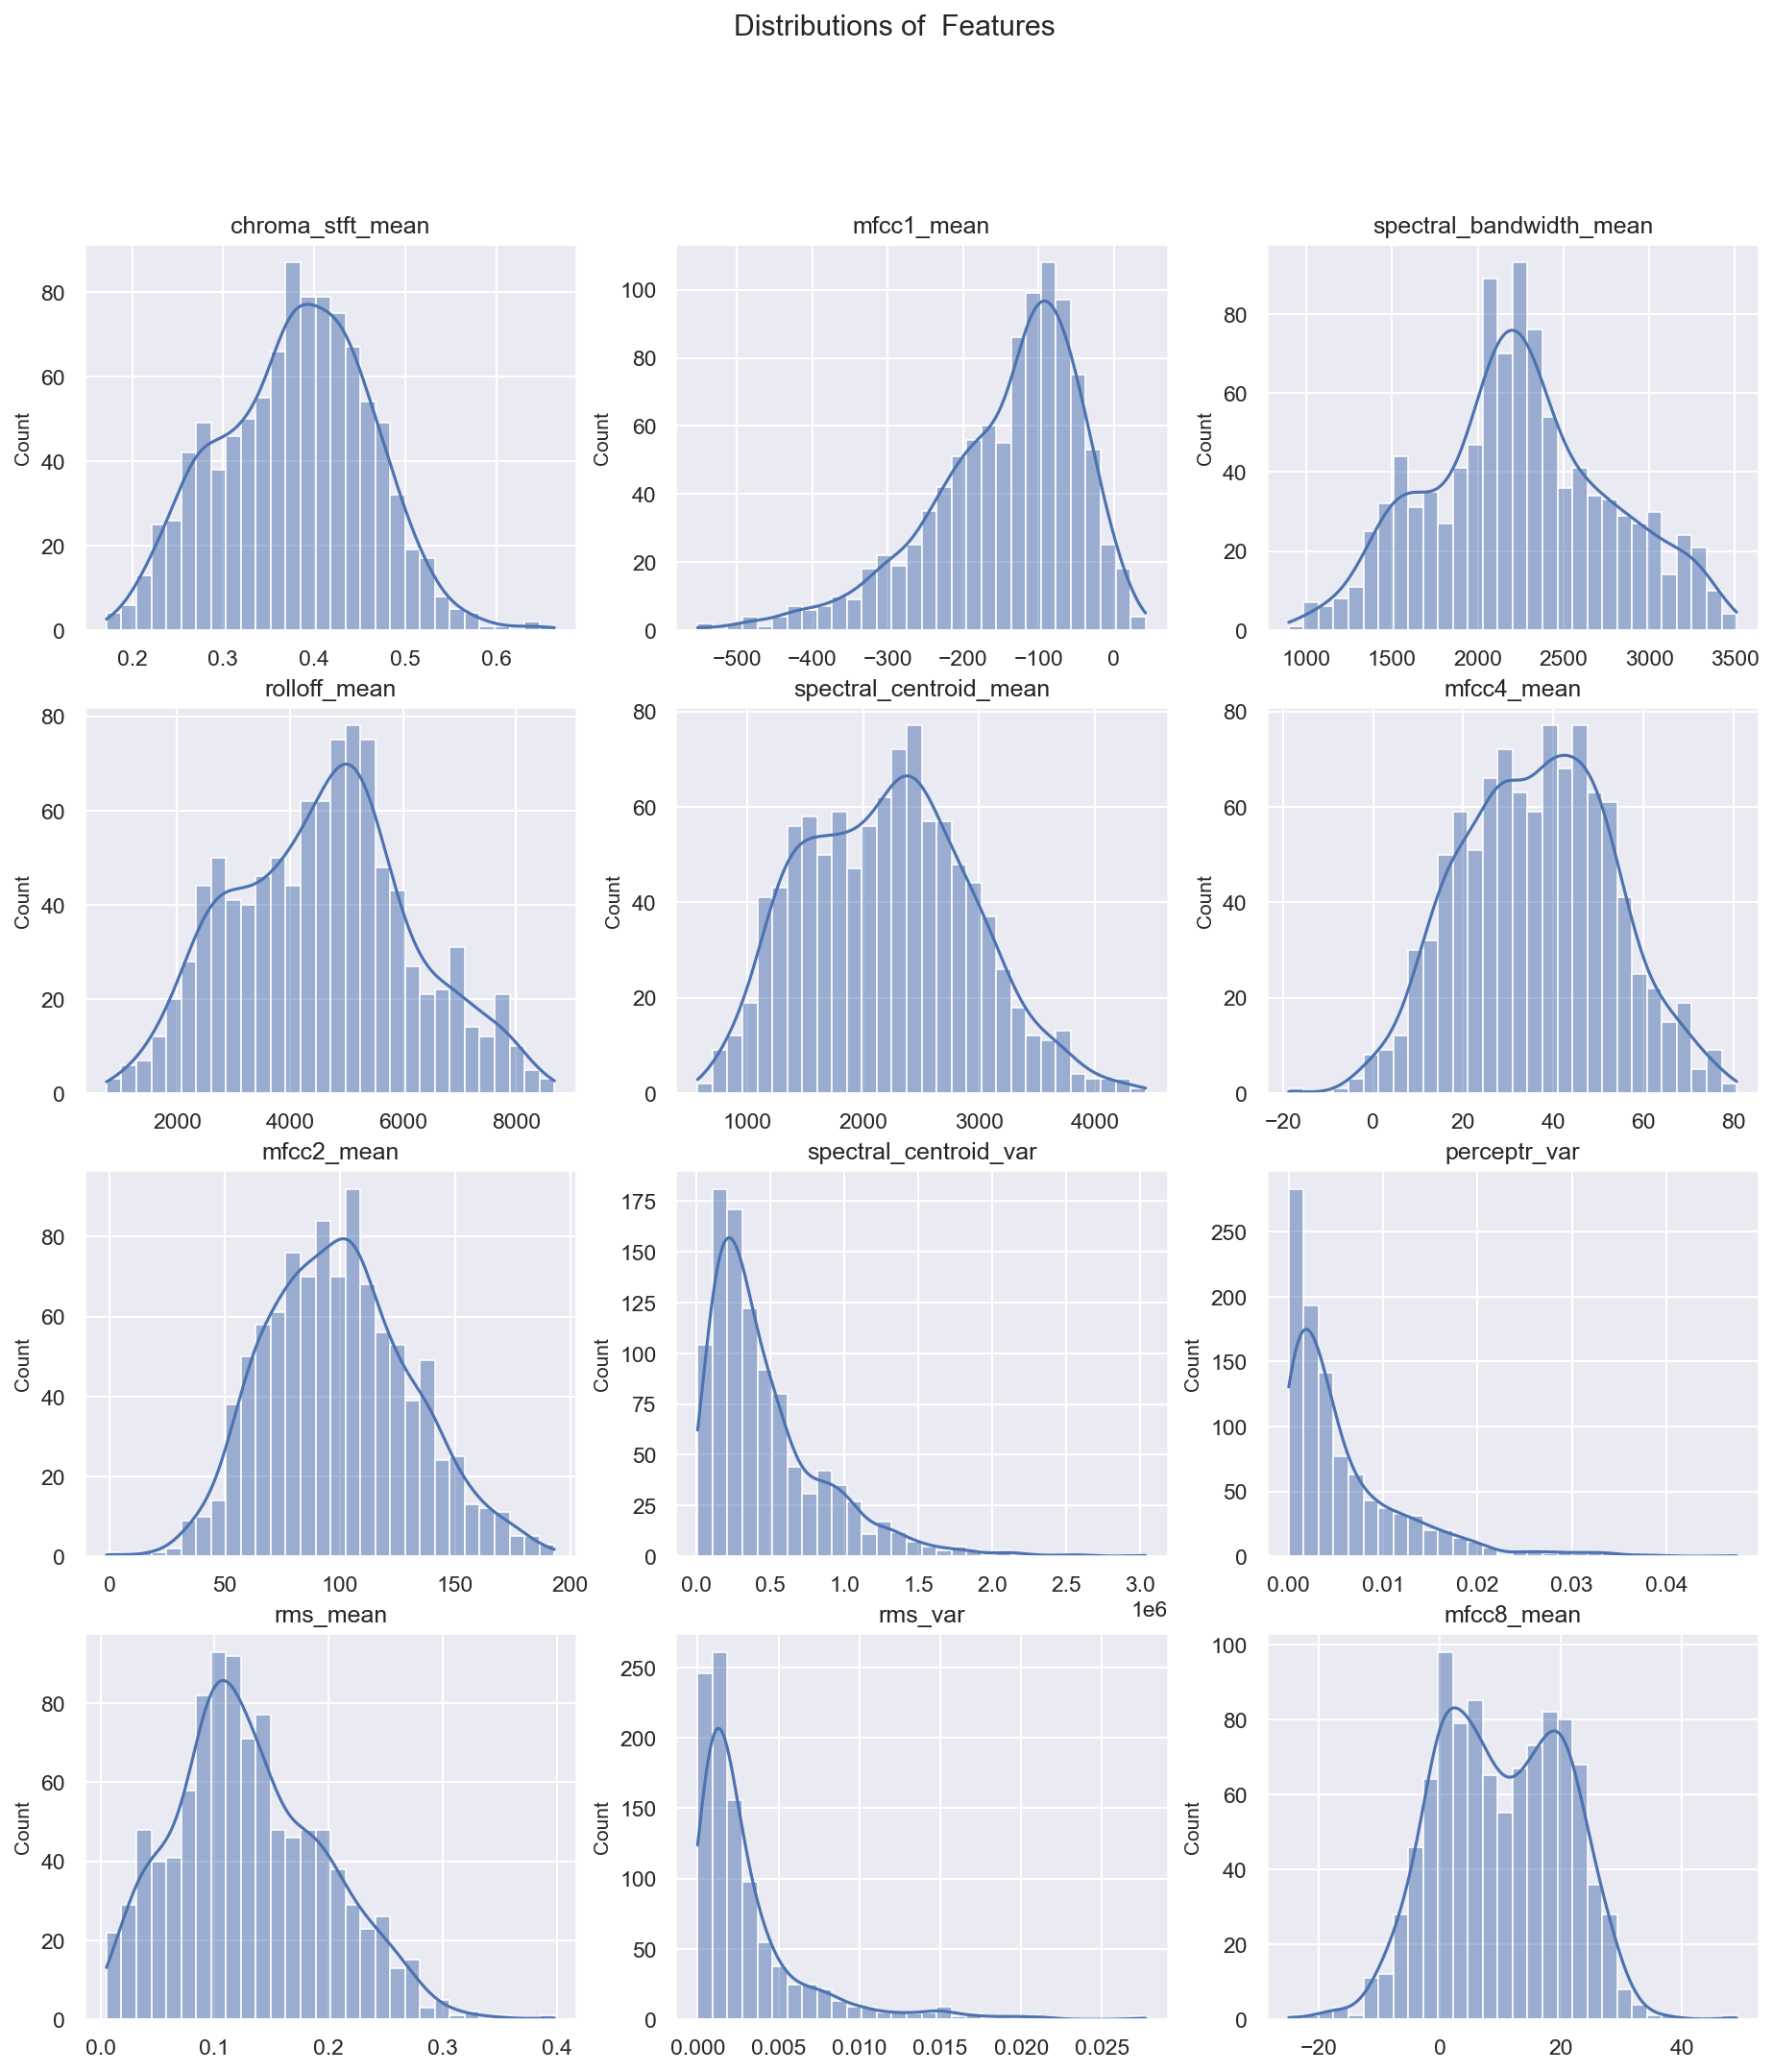

Figure saved: figs/5511_final_project/feature_correlation.png


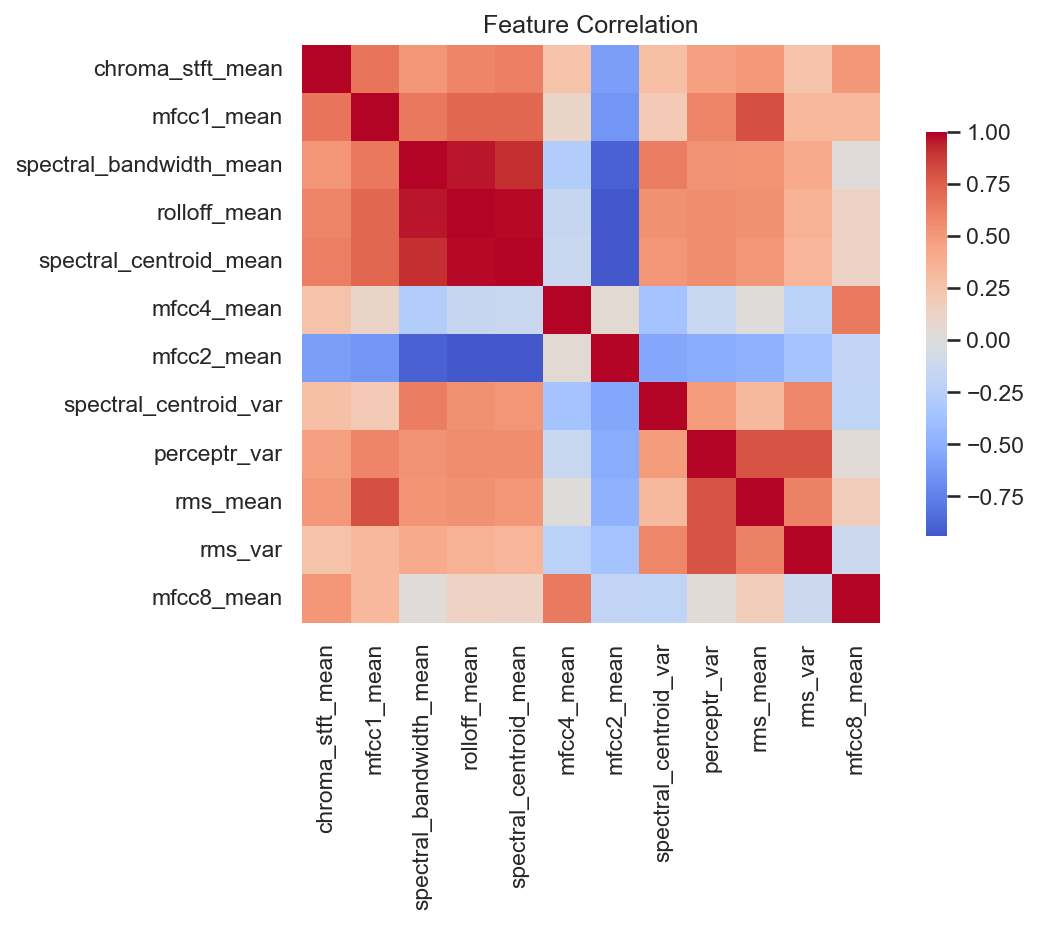

In [57]:
def visualize_genre_differences(features_df):
    """
    Create comprehensive visualizations showing differences between genres
    with normalization for feature discrimination analysis
    """

    # Get feature columns (exclude filename and label)
    feature_cols = [col for col in features_df.columns if col not in ['filename', 'label']]

    # 1. Heatmap with normalized features
    plt.figure(figsize=(12,8))

    # Normalize features first
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(features_df[feature_cols])
    features_normalized = pd.DataFrame(X_normalized, columns=feature_cols,
                                       index=features_df.index)
    features_normalized['label'] = features_df['label']

    genre_means_norm = features_normalized.groupby('label')[feature_cols].mean()
    sns.heatmap(genre_means_norm.T, annot=False, cmap='RdBu_r', center=0,
                cbar_kws={'label': 'Normalized Feature Value'})
    plt.title('Normalized Feature Values by Genre\n' +
              'Red = Above average for this feature, Blue = Below average for this feature\n' +
              'White = Close to the overall dataset average')
    plt.xlabel('Genre')
    plt.ylabel('Features')
    plt.tight_layout()
    save_figure('normalized_feature_heatmap')
    plt.show()

    # 1. Between-class vs within-class variance ratio - Fisher Analysis
    plt.figure(figsize=(10,6))

    variance_ratios = {}
    for feature in feature_cols:
        # Calculate between-class variance
        overall_mean = features_df[feature].mean()
        between_var = 0
        total_samples = len(features_df)

        for genre in features_df['label'].unique():
            genre_data = features_df[features_df['label'] == genre]
            genre_mean = genre_data[feature].mean()
            genre_size = len(genre_data)
            between_var += genre_size * (genre_mean - overall_mean) ** 2

        between_var /= (len(features_df['label'].unique()) - 1)

        # Calculate within-class variance
        within_var = 0
        for genre in features_df['label'].unique():
            genre_data = features_df[features_df['label'] == genre]
            within_var += genre_data[feature].var() * (len(genre_data) - 1)

        within_var /= (total_samples - len(features_df['label'].unique()))

        # Calculate ratio (Fisher's ratio)
        if within_var > 0:
            variance_ratios[feature] = between_var / within_var
        else:
            variance_ratios[feature] = 0

    variance_ratio_series = pd.Series(variance_ratios).sort_values(ascending=False)
    top_ratio_features = variance_ratio_series.head(12)
    key_features = top_ratio_features.index

    plt.barh(range(len(top_ratio_features)), top_ratio_features.values)
    plt.yticks(range(len(top_ratio_features)), top_ratio_features.index)
    plt.xlabel('Between-class / Within-class Variance Ratio')
    plt.title('Feature Discrimination Power\n(Fisher Ratio: Higher = Better Genre Separation)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    save_figure('feature_discrimination_power')
    plt.show()

    # 3. Box plots for key features
    # Calculate the grid size needed
    n_features = len(key_features)
    n_cols = 3  # You can adjust this as needed
    n_rows = (n_features + n_cols - 1) // n_cols  # This ensures enough rows
    colours = sns.color_palette(n_colors=len(key_features))

    # Create the subplot grid with the correct size
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.ravel()

    for i, feature in enumerate(key_features):
        sns.boxplot(data=features_df, x='label', y=feature, ax=axes[i], color=colours[i])
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_title(f'{feature} by Genre')

    # Hide any unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.suptitle('Key Audio Features by Genre (from Fisher ratios)', fontsize=14, y=1.02)
    save_figure('genre_box_plots')
    plt.show()

    # Distributions
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.ravel()

    for i, feature in enumerate(key_features):
        ax = axes[i]
        sns.histplot(features_df[feature].dropna(), bins=30, kde=True, ax=ax)
        ax.set_title(feature)
        ax.set_xlabel("")
        ax.set_ylabel("Count")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Distributions of  Features")
    save_figure("")
    plt.show()

    # Correlation heatmap
    corr = features_df[key_features].corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, square=True, annot=False, cbar_kws={"shrink": 0.7})
    plt.title("Feature Correlation")
    save_figure("feature_correlation")
    plt.show()

    return genre_means_norm, variance_ratio_series, key_features

genre_stats, fisher_rankings, key_features = visualize_genre_differences(features_30_sec)

### 6) Principal Component Analysis - Do the genres form natural clusters?

In [58]:
# Functions for basic PCA analysis and naive clustering
# Code culled from 5510_final_project, ugly but works for this purpose.
def pca_analysis(features_df):

    # Get feature columns (exclude filename and label)
    feature_cols = [col for col in features_df.columns if col not in ['filename', 'label']]

    # 2. PCA visualization
    X = features_df[feature_cols]
    y = features_df['label']

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA
    pca = PCA(n_components=5)
    X_pca = pca.fit_transform(X_scaled)

    # Get the components (loadings)
    components = pca.components_
    n_components = components.shape[0]

    # Create a DataFrame for easier interpretation
    loadings_df = pd.DataFrame(
        components.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=feature_cols
    )

    # Explained variance ratio
    print(f"\nExplained Variance Ratio:")
    for i, var_ratio in enumerate(pca.explained_variance_ratio_[:n_components]):
        print(f"PC{i+1}: {var_ratio:.3f} ({var_ratio*100:.1f}%)")

    print(f"\nCumulative Explained Variance: {pca.explained_variance_ratio_[:n_components].sum():.3f}")

    plt.figure(figsize=(12,8))
    genres = features_df['label'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))

    for genre, color in zip(genres, colors):
        mask = y == genre
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color], label=genre, alpha=0.6, s=50)

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title('Genre Clusters in Feature Space (PCA)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    save_figure('genre_clusters_pca')
    plt.show()

    return loadings_df,X_pca

# Reusing the function I built in 5510 final project.
def plot_pca_loadings(loadings_df, key_features=None):
    # Plot PCA loadings for the first n components
    n_components = loadings_df.shape[1]

    # Filter to key features if provided
    if key_features is not None:
        # Only keep features that exist in both key_features and loadings_df
        available_key_features = [f for f in key_features if f in loadings_df.index]
        loadings_df_filtered = loadings_df.loc[available_key_features]
        print(f"Showing {len(available_key_features)} key features out of {len(loadings_df)} total features")
    else:
        loadings_df_filtered = loadings_df
        print(f"Showing all {len(loadings_df)} features")


    fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 6))

    for i in range(n_components):
        pc = f'PC{i+1}'
        loadings = loadings_df_filtered[pc].sort_values(key=abs, ascending=True)

        # Create horizontal bar plot
        bars = axes[i].barh(range(len(loadings)), loadings.values)

        # Color bars based on positive/negative
        for j, bar in enumerate(bars):
            if loadings.values[j] >= 0:
                bar.set_color('skyblue')
            else:
                bar.set_color('salmon')

        axes[i].set_yticks(range(len(loadings)))
        axes[i].set_yticklabels(loadings.index)
        axes[i].set_xlabel('Loading Value')
        title = f'PCA{i} Loadings'
        axes[i].set_title(title)
        axes[i].axvline(x=0, color='black', linestyle='--', alpha=0.5)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    save_figure(f'pca_loadings_top_{n_components}')
    plt.show()
    return

def pca_plot(pca_data, k=2,  pc1 = 0, pc2 = 1, filename = 'kMeans pca_plot'):
    kMeans_music = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_pca)
    labels = kMeans_music.labels_
    unique_labels = np.unique(labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    # deviating from sns.cmap for better visible separation of clusters
    colours = colours = sns.color_palette(n_colors=len(unique_labels))

    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
                   c=[colours[i]], alpha=0.7, s=50)

    plt.xlabel(f'PC1')
    plt.ylabel(f'PC2')
    plt.title(f'K-Means Clusters for GTZAN Data in PCA Space')
    #plt.legend(title='Genre Groups', loc='best')
    save_figure(filename)
    plt.show()
    return


Explained Variance Ratio:
PC1: 0.236 (23.6%)
PC2: 0.167 (16.7%)
PC3: 0.106 (10.6%)
PC4: 0.075 (7.5%)
PC5: 0.045 (4.5%)

Cumulative Explained Variance: 0.628
Figure saved: figs/5511_final_project/genre_clusters_pca.png


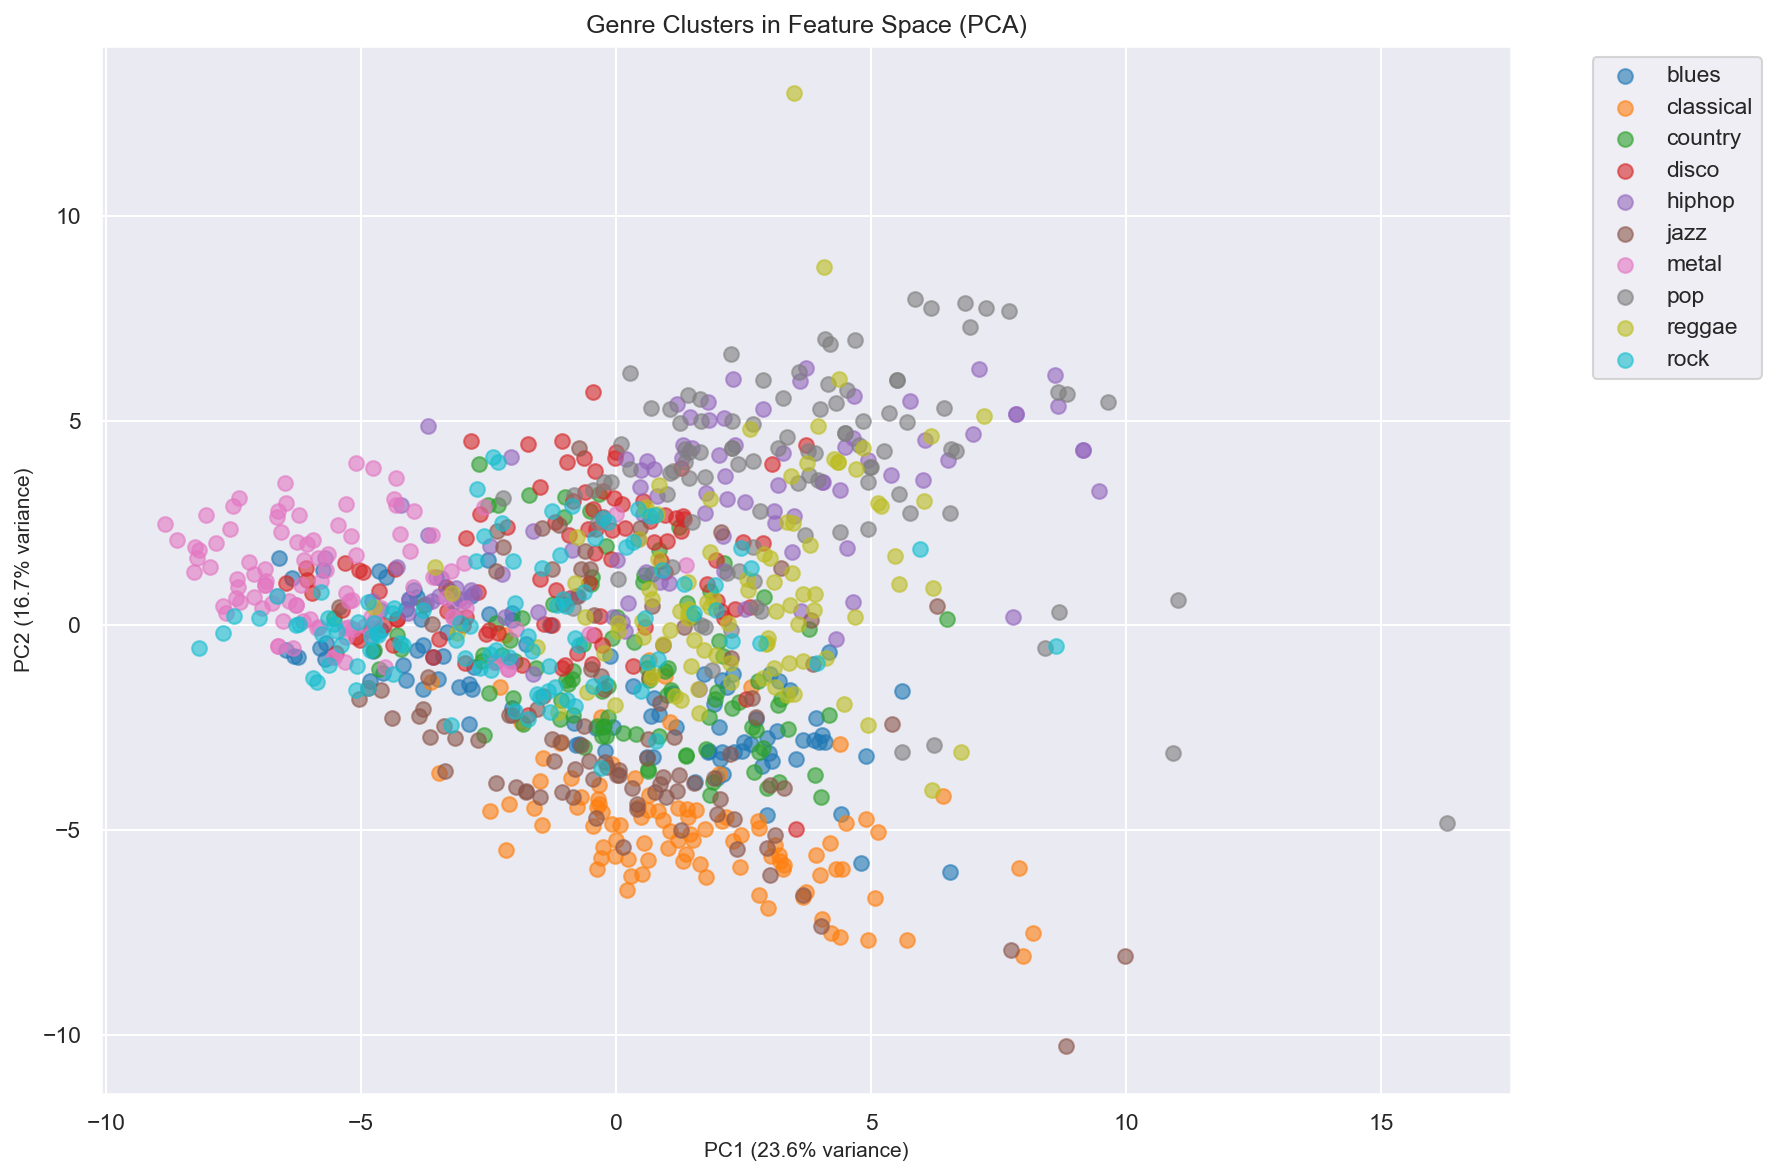

Showing 12 key features out of 58 total features
Figure saved: figs/5511_final_project/pca_loadings_top_5.png


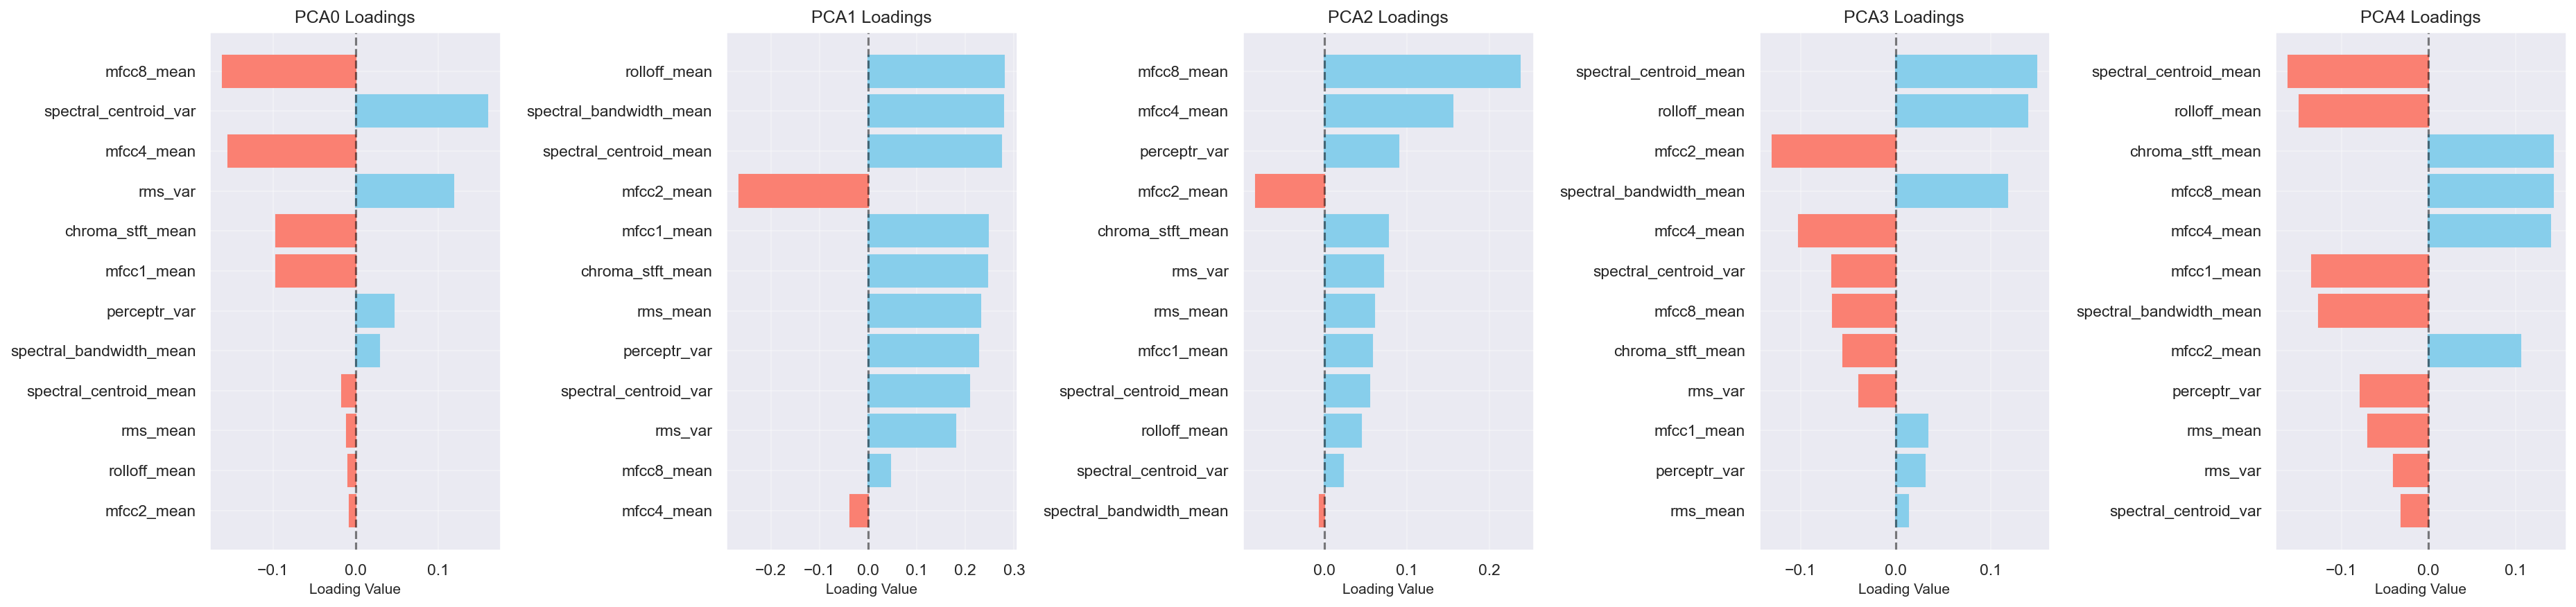

Figure saved: figs/5511_final_project/kMeans_pca_plot.png


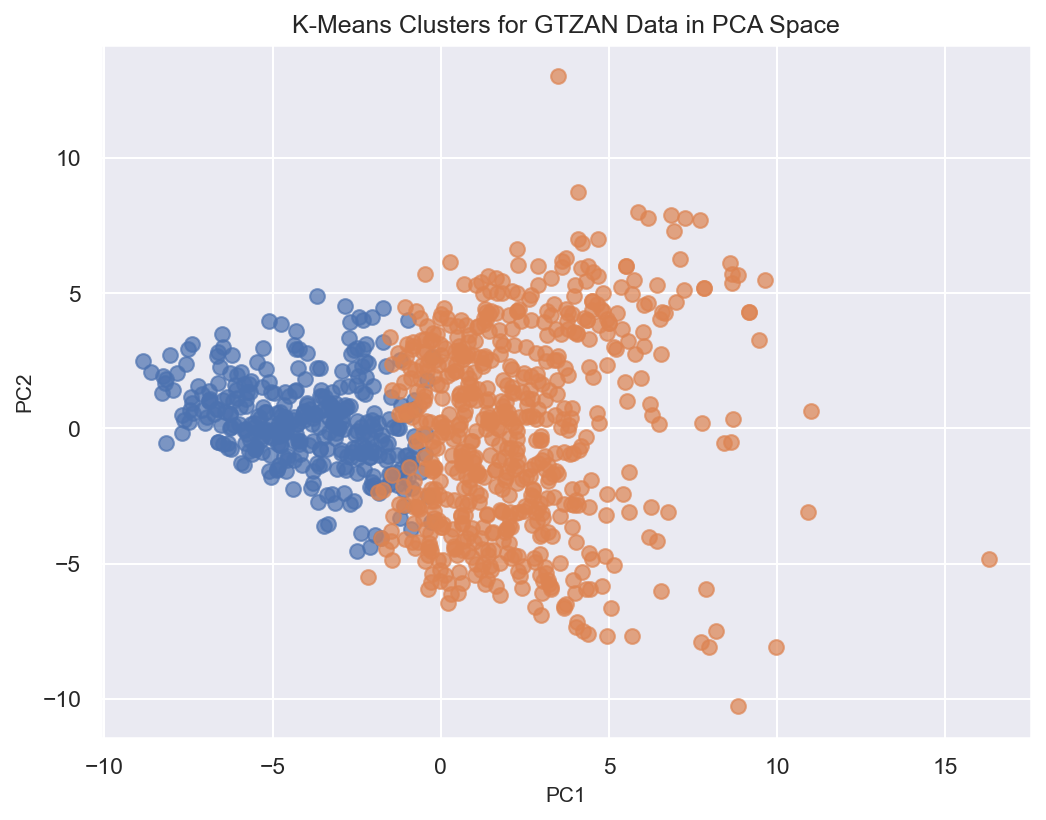

Figure saved: figs/5511_final_project/kMeans_pca_plot.png


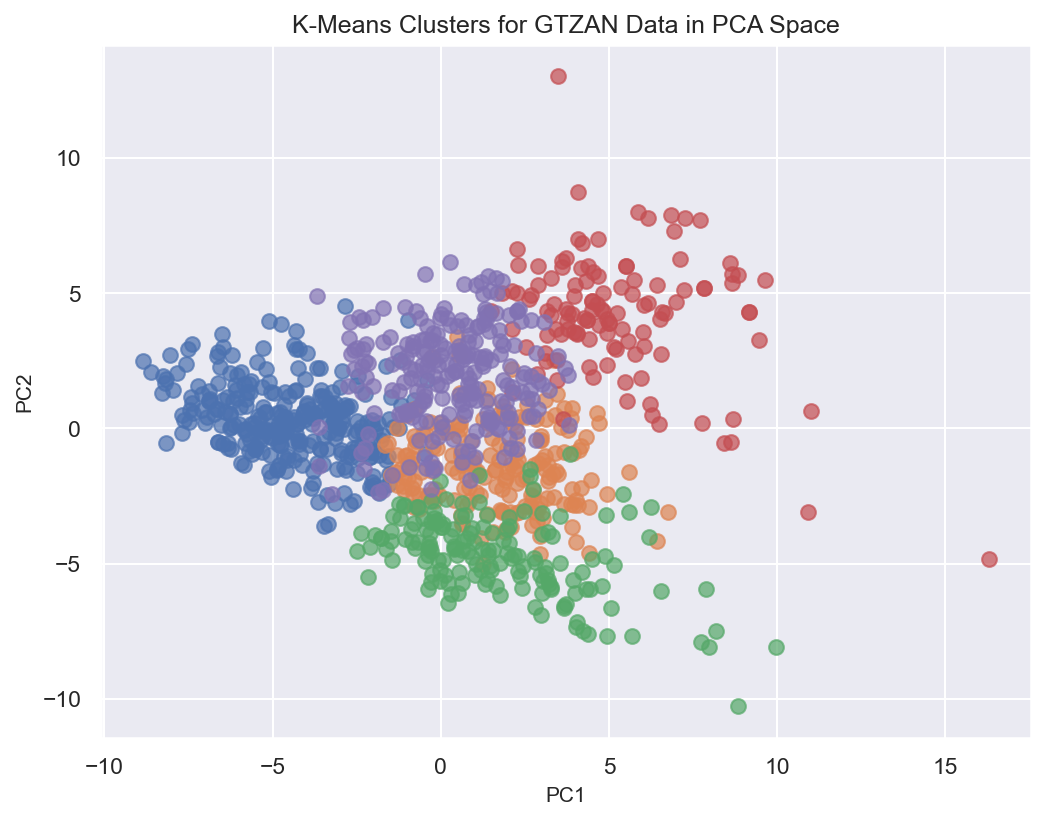

In [59]:
# Develop PCA
loadings_df,X_pca = pca_analysis(features_df=features_30_sec)
plot_pca_loadings(loadings_df, key_features=key_features)
# Then plot clusters (n_clusters = 2 and 5, seem to work best)
pca_plot(pca_data = X_pca, k=2, pc1 = 0, pc2 = 1)
pca_plot(pca_data = X_pca, k=5, pc1 = 0, pc2 = 1)

### EDA Summary Findings

This EDA reveals a well-structured dataset with strong discriminative features that should support effective genre classification models.

#### Dataset Overview
- 1,000 audio files across 10 music genres (100 per genre)
- Balanced dataset - equal representation across all genres
- Just one missing value(file) jazz.00054.wav -> should have jazz00054png
- Audio files are 30-second clips at consistent sample rates
- I have yet to look at the 3-sec clips, which may improve classification accuracy (1000 samples per genre, 10000 total samples)

**Key Distinguishing Features Found:**
- **Tempo**: Varies significantly by genre, disco has consistent dance tempos, classical more variable. (surprisingly not ranking in the Fisher Analysis)
- **Spectral Centroid**: Metal/pop/disco have higher "brightness," classical/blues/jazz tends toward lower frequencies
- **RMS Energy**: Metal/rock show highest energy levels, classical more dynamic range
- **MFCC Patterns**: Each genre has distinctive spectral shape signatures (in particular mffcc 1 - 4)

**Most Discriminative Features (for Genre Separation):**
1. **`chroma_stft_mean`** - Musical note content
2. **`mfcc1_mean`** - Primary spectral shape
3. **`spectral_bandwidth_mean`** - Frequency spread
4. **`rolloff_mean`** - High-frequency cutoff
5. **`spectral_centroid_mean`** - Sound brightness

**Feature Relationships:**
- Strong correlations between related features (e.g., spectral features)
- MFCC features capture complementary timbral information
- Energy features (RMS) correlate with perceived loudness by genre
- Most features show normal or near-normal distributions, with some skewed distributions in energy-related features
- Outliers are present but no rationale to think these are not legitimate genre characteristics

#### **Genre Clustering Insights:**

**Principal Components**

PC0
Strong positive loadings: spectral_centroid_var, rms_var → variance in brightness (centroid) and variance in loudness (RMS).
Negative loadings: mfcc8_mean, mfcc4_mean → higher-order cepstral coefficients (related to timbre / texture).
Interpretation: PC0 separates tracks by variability in energy/brightness vs. timbre smoothness.

PC1
Strong positive: rolloff_mean, spectral_bandwidth_mean, spectral_centroid_mean → all linked to brightness/high-frequency emphasis.
Negative: mfcc2_mean (related to spectral slope).
Interpretation: PC1 mostly captures overall brightness / treble vs bass balance.

PC2
Strong positive: spectral_centroid_mean, rolloff_mean, mfcc2_mean again.
Interpretation: Another brightness-oriented axis, but maybe separating high-frequency emphasis from smoothness.

PC3
Mix of negatives on mfcc2_mean, mfcc4_mean, positives on spectral_centroid_mean, rolloff_mean.
Interpretation: A timbre–brightness tradeoff.

PC4
Strong positive: chroma_stft_mean, mfcc features.
Negative: spectral_centroid_mean, rolloff_mean.
Interpretation: May capture harmonic content (chroma) vs. spectral brightness.

**PCA Visualization**
- **2 major clusters** emerge naturally (developed vs. less developed musical complexity)
- **5 clusters** provide more meaningful separation but there is quite some overlap, potential compositions (have not spent much time on it):
  - High-energy genres (metal, rock)
  - Rhythmic genres (disco, pop)
  - Complex harmonic genres (jazz, classical)
  - Traditional genres (blues, country)
  - Modern genres (hip-hop, reggae)

#### Data Quality & Preprocessing Needs

- Features have vastly different scales (tempo ~60-200, MFCCs in thousands) so Normalization essential
- High discriminative power across the feature set but Rredundancy exists among spectral features _(hence looking at reduction via PCA)_
- Dataset size (1,000 samples) suitable for ML, but may be worth also preparing to use 3-sec clips with caution.
- Balanced classes eliminate need for complex sampling strategies

**Potential Challenges**
- Genre boundaries are vaguely defined and can be subjective (some overlap expected)
- Limited temporal information (30-second clips may miss song structure)
- Many features - curse of dimensionality?

## 2. Preprocessing

My initial thoughts on what I want to do for modelling are as follows:
1) Train and evaluate a Baseline CNN model using the log-mel spectrograms.
2) Train and evaluate a classical ML model using the Features with PCA.
3) Combine (1) and (2) to create a hybrid model using some form of early/mid feature fusion.
4) Time allowing, it would be interesting to compare with a commercially available model such as EfficientNet.
5) Further, there is the possibility to use the 3-sec clips to improve the model.

Pre-processing sequence to prepare for the modelling requirements:
- Add a png_filename column to the dataframe (to make it easier to retrieve images)
- Convert genre labels to integers.
- Train/val/test split (80/10/10)
- Normalize features (standardize) - fit to train only to avoid leakage.
- Apply PCA to reduce dimensionality (fit on train only) - but will keep more components than in EDA (enough to explain 90% variance)
- I considered converting .png files to .tfrecords based on my experiences in the previous week's module. However, given the small size of the data, I am only going to do this if I struggle with training time locally.
- Apply 'Spec Augment' augmentation to spectrograms (train only)
- function to produce 1-channel or 3-channel images - to support using EfficientNet etc.
- Build Tensorflow Datasets

**_Note:_**
SpecAugment is a data augmentation technique designed for spectrograms and is widely used in music/audio. The key idea:
- Randomly mask out blocks of frequency bins and/or time frames in the spectrogram.
- This forces the network to not rely too heavily on very narrow bands (e.g., a specific frequency peak, or a specific timing cue).
- It’s like dropout, but in the 2D spectrogram domain. So the model learns more robust and general features.

In [60]:
# Add png_filename column to the dataframe (to make it easier to retrieve images)
# I may want to do all of this later with features_3_sec
# Remember to remove the row we found with a missing spectrogram
features_df = features_30_sec.copy()

features_df['png_filename'] = features_df['filename'].apply(
    lambda x: x.replace('.wav', '').replace('.', '') + '.png')

features_df['png_path'] = features_df.apply(
    lambda row: IMAGES_DIR / row['label'] / row['png_filename'], axis=1)

# Filter out rows where PNG doesn't exist
initial_count = len(features_df)
features_df = features_df[features_df['png_path'].apply(os.path.exists)]
final_count = len(features_df)

print(f"Removed {initial_count - final_count} rows with missing PNG files")
print(f"Remaining rows: {final_count}")

Removed 1 rows with missing PNG files
Remaining rows: 999


In [61]:
#Set up global variables
ID_COL     = "filename"
IMG_PATH    = "png_path"
IMG_NAME    = "png_filename"
LABEL_COL  = "label"
NON_FEATURE = {ID_COL, LABEL_COL, IMG_NAME, IMG_PATH}
FEATURE_COLS = [c for c in features_df.columns if c not in NON_FEATURE]

#Convert labels to integers and track for final decoding
NUM_CLASSES = features_df[LABEL_COL].nunique()
CLASS_NAMES = sorted(features_df[LABEL_COL].unique())
CLASS2IDX   = {c:i for i,c in enumerate(CLASS_NAMES)}
features_df["label_idx"] = features_df[LABEL_COL].map(CLASS2IDX).astype(np.int32)
print(CLASS2IDX)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [62]:
# Train/Val/Test split (80/10/10)
train_df, tmp_df = train_test_split(
    features_df, test_size=0.20, random_state=SEED, stratify=features_df[LABEL_COL]
)
val_df, test_df  = train_test_split(
    tmp_df, test_size=0.50, random_state=SEED, stratify=tmp_df[LABEL_COL]
)
print(f"Train {len(train_df)}, Val {len(val_df)}, Test {len(test_df)}")

Train 799, Val 100, Test 100


In [63]:
# Apply Normalization and Principal Component Analysis
PCA_VARIANCE = 0.90       # keep enough components to explain 90% variance

scaler = StandardScaler().fit(train_df[FEATURE_COLS].values)

X_train_scaled = scaler.transform(train_df[FEATURE_COLS].values).astype("float32")
X_val_scaled   = scaler.transform(val_df[FEATURE_COLS].values).astype("float32")
X_test_scaled  = scaler.transform(test_df[FEATURE_COLS].values).astype("float32")

pca = PCA(n_components=PCA_VARIANCE, svd_solver="full", random_state=SEED).fit(X_train_scaled)
expl_var = pca.explained_variance_ratio_.sum()
n_comps  = pca.n_components_
print(f"PCA keeps {n_comps} comps; explained variance ≈ {expl_var:.3f}")

def transform_feats_with_pca(df, X_scaled):
    y = df["label_idx"].values.astype("int32")
    paths = df[IMG_PATH].values.astype("object")
    X_pca = pca.transform(X_scaled).astype("float32")
    return paths, X_pca, y

train_paths, train_feats, train_labels = transform_feats_with_pca(train_df, X_train_scaled)
val_paths,   val_feats,   val_labels   = transform_feats_with_pca(val_df,   X_val_scaled)
test_paths,  test_feats,  test_labels  = transform_feats_with_pca(test_df,  X_test_scaled)

PCA keeps 23 comps; explained variance ≈ 0.901


In [64]:
# Augment spectrograms and create Tensorflow Datasets
IMG_SIZE = (224, 224)   # doing this to allow input into EfficientNet for comparison
CHANNELS = 3            # feed RGB to the CNN (not the RGBA of original)
IMAGE_SHAPE = (*IMG_SIZE, CHANNELS)
BATCH    = 16
AUTOTUNE = tf.data.AUTOTUNE
# convert RGBA png files to resized RGB tf.image
def decode_png(path):
    raw = tf.io.read_file(path)
    # Decode as 4 channels (RGBA), then drop alpha
    img = tf.image.decode_png(raw, channels=4)  # HxWx4, uint8
    # This code, changed after debugging, it deals with the alpha channel explicitly
    # It rescales the alpha channel to 0..1 mask and then multiplies it by the RGB channels
    # effectively replacing transparent pixels with black.
    rgb, a = img[..., :3], tf.cast(img[..., 3:], tf.float32) / 255.0
    rgb = tf.cast(rgb, tf.float32)                 # now rgb is 0..255 float32
    rgb = rgb * a + (1.0 - a) * 0.0                # composite on black
    rgb = tf.image.resize_with_pad(rgb, IMG_SIZE[0], IMG_SIZE[1], antialias=True)
    return rgb                                     # IMPORTANT: 0..255 float32

# SpecAugment- a simplified version of it
def spec_augment(img, max_freq_mask=32, max_time_mask=32):
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]
    # Frequency mask - a strip at a random frequency position
    f = tf.random.uniform([], 0, max_freq_mask, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, tf.maximum(h - f, 1), dtype=tf.int32)
    mask_f = tf.concat([tf.ones([f0, w, 1]), tf.zeros([f, w, 1]), tf.ones([h - f0 - f, w, 1])], axis=0)
    # Time mask - a strip at a random time position
    t = tf.random.uniform([], 0, max_time_mask, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, tf.maximum(w - t, 1), dtype=tf.int32)
    mask_t = tf.concat([tf.ones([h, t0, 1]), tf.zeros([h, t, 1]), tf.ones([h, w - t0 - t, 1])], axis=1)
    # multiplication - to zero out a block of frequencies and a block of times
    img = img * mask_f * mask_t
    return img

# More complex SpecAugment created with AI in an effort to combat observed overfitting
def enhanced_spec_augment(img, max_freq_mask=40, max_time_mask=40, num_masks=2):
    """More aggressive SpecAugment"""
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    # Apply multiple frequency masks
    for _ in range(num_masks):
        f = tf.random.uniform([], 0, max_freq_mask, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, tf.maximum(h - f, 1), dtype=tf.int32)
        mask_f = tf.concat([
            tf.ones([f0, w, 1]),
            tf.zeros([f, w, 1]),
            tf.ones([h - f0 - f, w, 1])
        ], axis=0)
        img = img * mask_f

    # Apply multiple time masks
    for _ in range(num_masks):
        t = tf.random.uniform([], 0, max_time_mask, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, tf.maximum(w - t, 1), dtype=tf.int32)
        mask_t = tf.concat([
            tf.ones([h, t0, 1]),
            tf.zeros([h, t, 1]),
            tf.ones([h, w - t0 - t, 1])
        ], axis=1)
        img = img * mask_t

    # Add noise
    noise = tf.random.normal(tf.shape(img), stddev=0.01)
    img = img + noise

    return img


In [65]:
# Function to create datasets
ENHANCED_SPEC_AUGMENT = False

def make_ds(paths, feats, labels, training=False):
    # need to convert path to string for tf.data.Dataset, probably I should have saved as string in the first place
    path_strings = [str(path) for path in paths]
    ds_img  = tf.data.Dataset.from_tensor_slices(path_strings).map(decode_png, num_parallel_calls=AUTOTUNE)
    ds_feat = tf.data.Dataset.from_tensor_slices(feats)
    ds_lab  = tf.data.Dataset.from_tensor_slices(labels)

    ds = tf.data.Dataset.zip(((ds_img, ds_feat), ds_lab))
    if training:
        # Turning on Spec Augment now that I have reasonable base accuracy
        # Added enhanced_spec_augment to try to combat overfitting 14/10 09:20
        if ENHANCED_SPEC_AUGMENT:
            ds = ds.map(lambda x, y: ((enhanced_spec_augment(x[0]), x[1]), y), num_parallel_calls=AUTOTUNE)
        else:
            ds = ds.map(lambda x, y: ((spec_augment(x[0]), x[1]), y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1000, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_feats, train_labels, training=True)
val_ds   = make_ds(val_paths,   val_feats,   val_labels,   training=False)
test_ds  = make_ds(test_paths,  test_feats,  test_labels,  training=False)

In [66]:
# Using these helper functions to create datasets for each of the models I want to compare
# These functions become the inputs to the model builders.
def use_image_only(ds):
    # ((img, feats), y) -> (img, y)
    return ds.map(lambda x, y: (x[0], y), num_parallel_calls=AUTOTUNE)

def use_features_only(ds):
    # ((img, feats), y) -> (feats, y)
    return ds.map(lambda x, y: (x[1], y), num_parallel_calls=AUTOTUNE)

def use_hybrid(ds):
    # already ((img, feats), y), so doesn't actually make a change.
    return ds

## 3. Model Architecture

I will create builder functions for each of the models that I want to compare. Then use an 'Experiment' class to compare the models, in the same way that I did for the previous week's module. The class will have methods to call the builder functions, train, evaluate and save results.

**_Note:_**
I will use the following models:
- Baseline CNN
- Classical ML model (selecting from sklearn library)
- Hybrid model
- EfficientNet

Architectures are described under each model sub-heading.

### Baseline CNN

There is no attempt to do anything fancy here. The CNN is built as follows:
- Input: 288x432x3 (RGB)
- 4 x Conv2D: 32 -> 64 - > 128 -> 256 filters, with kernel size 3x3, stride 1, padding 'same', activation 'relu'
- Kernel Regularization - see note
- MaxPool2D: 2x2, strides 2 and BatchNormalization applied between each layer

- GlobalAveragePooling2D to create input for Dense layers
- Dense: 256, activation 'relu'
- Dropout: 0.4
- Dense: number of genres, activation 'softmax'

**Note from research:** This L2 Kernel Regularization applied to CNNs for GTZAN potentially reduces the likelihood of over-fitting by causing model weights to slowly tend to zero. Just trying it out. Apparently the combination of L2 weight decay + BatchNorm + MaxPool are quite standard tricks.

**Note from research:** Stepping up filters (32 -> 64 - > 128 -> 256) when interpreting log-mel spectrograms:
- Low-level features: vertical edges = onsets, horizontal edges = harmonics, diagonal = sweeps/glides.
- Mid-level features: repeating textures = rhythm patterns, spectral envelopes.
- High-level features: genre-relevant signatures (distorted guitar energy, drum kit frequency patterns, violin timbre).
So stepping up filters allows deeper layers to learn a richer vocabulary of patterns while the spatial dimension shrinks.

In [67]:
# Note: increased regularizattion from 1e-4 to 5e-4 to combat over-fitting
# I had previously reduced it to 1e-5 to see if it was causing low accuracy
def build_baseline_cnn(image_shape=IMAGE_SHAPE, num_classes=NUM_CLASSES, l2=5e-4):
    img_in = keras.Input(shape=image_shape, name="spec_img")

    x = layers.Conv2D(32, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(img_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=img_in, outputs=out, name="BaselineCNN")

    model.compile(
    optimizer=keras.optimizers.Adam(1e-3),      # parameters to try 1e-3, 3e-4
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model

cnn_baseline_model = build_baseline_cnn(image_shape=IMAGE_SHAPE, num_classes=NUM_CLASSES)
cnn_baseline_model.summary()

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spec_img (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,698 (1.75 MB)

 Trainable params: 457,738 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

### Transfer Learning - Model Based on EfficientNet

I'm using the EfficientNetV2B0 model, it's the smallest variant of the V2 family from Google. It is a compact convolutional neural network optimized for both speed and accuracy, using fused MBConv blocks and progressive training strategies. With ~7M parameters, it achieves ~79% top-1 ImageNet accuracy while remaining efficient enough for transfer learning on modest datasets. This seems like a good fit for the GTZAN classification task.

**Note:** In order to benefit from the transfer learning, I have set up the 'build_transfer_model' function to include an initial training run with base.trainable set to 'False'. Then after the model has been 'warmed-up' meaning the classification dense layers have received some training, I set base.trainable to 'True' and recompile the model. In that way, the model does not forget its pre-training and is ready to improve performance in the real training run. Initially, I did try the whole thing with trainable=False, which yielded a test accuracy < 0.6.

In [68]:
# Transfer Learning Model
# NOTE: to get the benefit of the transfer learning, it is necessary to freeze the base model
# So that the model doesn't forget pre-training.
# Then afeter a period of training (the final layers), unfreeze part of the base to improve results
# Model: no external preprocess_input; EfficientNetV2 handles it internally
def build_transfer_model(image_shape=IMAGE_SHAPE, num_classes=NUM_CLASSES, model_name="efficientnetv2-s"):
    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False, input_shape=(224, 224, 3), weights="imagenet"
    )
    # Freeze for warm-up
    base.trainable = False

    inp = tf.keras.Input(shape=(224, 224, 3))
    x = base(inp, training=False)    # no preprocess_input here
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
    model = tf.keras.Model(inp, out)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss="sparse_categorical_crossentropy",
                      metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")])

    callbacks = [
        keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss"),
        keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor="val_acc")
    ]

    history_stage1 = model.fit(
        use_image_only(train_ds),
        validation_data=use_image_only(val_ds),
        epochs=15,
        callbacks=callbacks,
        verbose=2
    )

    # 1) Unfreeze
    base.trainable = True

    # trying without partial freezing

    #freeze_until = int(0.8 * len(base.layers))
    #for i, layer in enumerate(base.layers):
        #layer.trainable = (i >= freeze_until)

    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    # 2) Re-compile with a lower LR
    model.compile(
        optimizer=keras.optimizers.Adam(3e-5),  # smaller LR for fine-tuning
        loss="sparse_categorical_crossentropy",
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model

efficientnet_model = build_transfer_model(image_shape=IMAGE_SHAPE, num_classes=NUM_CLASSES)
efficientnet_model.summary()

Epoch 1/15
50/50 - 14s - 274ms/step - acc: 0.2040 - loss: 2.1866 - val_acc: 0.4500 - val_loss: 1.7938 - learning_rate: 1.0000e-03
Epoch 2/15
50/50 - 6s - 116ms/step - acc: 0.3204 - loss: 1.8924 - val_acc: 0.4300 - val_loss: 1.6020 - learning_rate: 1.0000e-03
Epoch 3/15
50/50 - 6s - 116ms/step - acc: 0.3867 - loss: 1.7313 - val_acc: 0.4800 - val_loss: 1.5626 - learning_rate: 1.0000e-03
Epoch 4/15
50/50 - 6s - 116ms/step - acc: 0.4043 - loss: 1.6719 - val_acc: 0.4300 - val_loss: 1.5399 - learning_rate: 1.0000e-03
Epoch 5/15
50/50 - 6s - 115ms/step - acc: 0.4168 - loss: 1.5623 - val_acc: 0.5800 - val_loss: 1.3840 - learning_rate: 1.0000e-03
Epoch 6/15
50/50 - 6s - 117ms/step - acc: 0.4481 - loss: 1.5621 - val_acc: 0.6100 - val_loss: 1.3127 - learning_rate: 1.0000e-03
Epoch 7/15
50/50 - 6s - 120ms/step - acc: 0.4318 - loss: 1.5362 - val_acc: 0.5100 - val_loss: 1.4489 - learning_rate: 1.0000e-03
Epoch 8/15
50/50 - 6s - 125ms/step - acc: 0.4981 - loss: 1.4605 - val_acc: 0.5600 - val_loss: 1.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,249,818 (23.84 MB)

 Trainable params: 6,128,602 (23.38 MB)

 Non-trainable params: 121,216 (473.50 KB)

### Features Only - Traditional ML Model

I will try out RandomForest, GradientBoosting and SVC (Support Vector) from the sklearn library. And, use the best alternative (evaluating on accuracy) for my comparisons.

Note: although RandomForest doesn't really need the scaling and PCA. I am going to use train_feats as the input to all three model options. If this was in the wild, maybe it would be worth revisiting this decision.

Based on this simple baseline run, SVC is the best performing. Depending on how the deep learning models perform, I may try to tune this SVC further during training phase. For an SVC, the parameter C determines regularization strength, high values of C tend towards overfitting, low values of C may have high bias and underfit. Given this is the only parameter I intend to vary, I simply tried some manual variations from 1 through 20, C=8 gave best test accuracy results.

In [69]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,          # try None, 10, 20
    min_samples_leaf=1,      # try 1, 2, 4
    n_jobs=-1,
    random_state=SEED
)
rf.fit(train_feats, train_labels)   # use your already-transformed features if you like; raw is fine too

val_pred  = rf.predict(val_feats)
test_pred = rf.predict(test_feats)

print("RF Val acc:", accuracy_score(val_labels, val_pred))
print("RF Test acc:", accuracy_score(test_labels, test_pred))

RF Val acc: 0.66
RF Test acc: 0.61


In [70]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,      # tune 0.02–0.2
    max_depth=None,          # tune None / small ints
    max_bins=255,
    random_state=SEED
)
hgb.fit(train_feats, train_labels)

val_pred  = hgb.predict(val_feats)
test_pred = hgb.predict(test_feats)

print("HGB Val acc:", accuracy_score(val_labels, val_pred))
print("HGB Test acc:", accuracy_score(test_labels, test_pred))

HGB Val acc: 0.6
HGB Test acc: 0.62


In [71]:
svc_classifier = SVC(
    kernel="rbf",
    C=8.0,
    gamma="scale",
    probability=True,
    random_state=42
)
svc_classifier.fit(train_feats, train_labels)

# Evaluate on val and test using the SAME pipeline
val_pred  = svc_classifier.predict(val_feats)
test_pred = svc_classifier.predict(test_feats)

print("SVM Val acc:", accuracy_score(val_labels, val_pred))
print("SVM Test acc:", accuracy_score(test_labels, test_pred))

SVM Val acc: 0.75
SVM Test acc: 0.66


### Hybrid Model

Definitely a first for me, built with help from AI. There are three parts:
1) The same CNN as used in step 1 - but stops one layer before classification.
2) Dense layers to process the PCAd features from the dataset
3) A Fusion layer that 'Concatenates' the two paths before applying a further dense layer and then Softmax for classification.

In [72]:
# Note: increased regularizattion from 1e-4 to 5e-4 to combat mild over-fitting
def build_hybrid_model(num_features, image_shape=IMAGE_SHAPE,
                       num_classes=NUM_CLASSES, l2=5e-4):
    # Image branch
    img_in = keras.Input(shape=image_shape, name="spec_img")
    x = layers.Conv2D(32, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(img_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    img_feats = layers.Dense(256, activation="relu")(x)
    img_feats = layers.Dropout(0.3)(img_feats)

    # Tabular branch
    feat_in = keras.Input(shape=(num_features,), name="handcrafted_feats")
    y = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(feat_in)
    y = layers.BatchNormalization()(y)
    y = layers.Dropout(0.2)(y)
    y = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(y)
    y = layers.Dropout(0.2)(y)

    # Fusion
    z = layers.Concatenate()([img_feats, y])
    z = layers.Dense(256, activation="relu")(z)
    z = layers.Dropout(0.4)(z)
    out = layers.Dense(num_classes, activation="softmax")(z)

    model = keras.Model(inputs=[img_in, feat_in], outputs=out, name="HybridCNN_Tabular")

    model.compile(
        optimizer=keras.optimizers.Adam(3e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model

hybrid_model= build_hybrid_model(num_features=train_feats.shape[1], image_shape=IMAGE_SHAPE, num_classes=NUM_CLASSES)
hybrid_model.summary()

Model: "HybridCNN_Tabular"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spec_img            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 224, 224,  │        896 │ spec_img[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ handcrafted_feats   │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 28, 28,    │    295,168 │ max_pooling2d_14… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │      3,072 │ handcrafted_feat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │      1,024 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_18[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                 

 Total params: 577,354 (2.20 MB)

 Trainable params: 576,138 (2.20 MB)

 Non-trainable params: 1,216 (4.75 KB)

## 4. Training

All the NN models are run for 30 epochs, based on observing the curves during multiple iterations this seemed sufficient without being overkill.
EarlyStopping proved problematic, the learning is not stable for all models and in the end I am almost ignoring this callback with a setting of patience=20.
It would have been interesting to play with more parameter tuning (e.g. learning rates), but time did not allow.

**Lesson Learned:** Going forward, I have to spend more time thinking about how to set up training and tuning in a more effective manner. It must be possible to:
1) Vary parameters easily and quickly - even though that may involve going back to 'pre-processing' as for changes to Spec Augment or require new model compilation as for changes to the learning rate.
2) Equally important, there needs to be a way to track results through these various changes. E.g. A data frame / database that holds the key info about the parameters of the training run and the results observed. (In this project I fell back to using comments to do this, a long long way from the effective way I want to work.)

### Debugging after initial training
**Situation after initial training runs:**

The cnn_baseline_model was ending with accuracy below 0.2, there was something substantially wrong with the model. As it is also the foundation for the hybrid approach, I think the hybrid result (which looked good) must have been purely due to the features. Having additionally trained the model on Kaggle with 100 epochs, I knew things weren't going to get better for cnn_baseline, but the hybrid model accuracy did improve to 0.85.

Debugging started with the following actions, trying to find out what is wrong:
- Try with a very small dataset, expecting overfitting, expecting quick training cycles. The results showed no improvement in accuracy and initially limited improvement in training cycle time.
- Check for dumb errors like mixing up class names or letting them vary between data sets. Found that I had used int64 for the label, whilst it works, I discovered this does slow down training. Observably quicker after I changed it to int32. Lesson: watch the auto-complete carefully.
- Check the data types are ok and match across train and validation. All looked good.
- Varied parameters for training (L2 regularization rate, EarlyStopping, number of epochs), no change.
- From pre-processing I tried turning on and off the Spec Augument functionality, which had no observable impact.
- Lastly, I used a version of EfficientNet direct from an AI recommendation - crucially: with a differing pre-processing step. This identified that the issue I had was about how I was processing the mel-spectrograms. By comparison, the same model on my pre-processed data sets had accuracy ~ 0.2 whilst with the new pre-processing it had ~0.6.

The provided mel spectrograms are in RGBA format (4 channels). In my initial code, I simply dropped the alpha channel. Turns-out this was overly simplistic and destroyed some of the signal being used by the models. Correcting this functionality in my code, largely solved the problem and allowed me to continue with the experimentation on other parameters.

In [73]:
# reduced EPOCHS to 30 from 40 based on observed results of flattening curvers 14/10 09:00
EPOCHS = 30

callbacks = [
    # reduced earlystopping from 20 to 8 14/10 09:00 to combat over-fitting
    keras.callbacks.EarlyStopping(
        patience=20,
        restore_best_weights=True,
        monitor="val_acc",
        mode="max",
        min_delta=0.001
    ),
    keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5, monitor="val_loss")
]

# 1) Baseline CNN
history_cnn = cnn_baseline_model.fit(
    use_image_only(train_ds),
    validation_data=use_image_only(val_ds),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose = 2
)
metrics_cnn = cnn_baseline_model.evaluate(use_image_only(test_ds), return_dict=True)

# 2) Hybrid
history_hybrid = hybrid_model.fit(
    use_hybrid(train_ds),
    validation_data=use_hybrid(val_ds),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose = 2
)
metrics_hybrid = hybrid_model.evaluate(use_hybrid(test_ds), return_dict=True)

# 3) EfficientNet
history_efficientnet = efficientnet_model.fit(
    use_image_only(train_ds),
    validation_data=use_image_only(val_ds),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose = 2
)
metrics_efficientnet = efficientnet_model.evaluate(use_image_only(test_ds), return_dict=True)

print("Test (Baseline CNN):",  metrics_cnn)
print("Test (Hybrid):",       metrics_hybrid)
print("Test (EfficientNet):", metrics_efficientnet)

Epoch 1/30
50/50 - 16s - 321ms/step - acc: 0.3104 - loss: 2.0468 - val_acc: 0.1000 - val_loss: 15.5443 - learning_rate: 1.0000e-03
Epoch 2/30
50/50 - 14s - 278ms/step - acc: 0.3792 - loss: 1.7786 - val_acc: 0.2200 - val_loss: 3.2873 - learning_rate: 1.0000e-03
Epoch 3/30
50/50 - 15s - 296ms/step - acc: 0.4793 - loss: 1.5939 - val_acc: 0.2900 - val_loss: 2.3198 - learning_rate: 1.0000e-03
Epoch 4/30
50/50 - 14s - 286ms/step - acc: 0.4756 - loss: 1.5626 - val_acc: 0.3100 - val_loss: 2.2507 - learning_rate: 1.0000e-03
Epoch 5/30
50/50 - 14s - 281ms/step - acc: 0.5131 - loss: 1.4801 - val_acc: 0.4300 - val_loss: 2.3207 - learning_rate: 1.0000e-03
Epoch 6/30
50/50 - 14s - 278ms/step - acc: 0.5369 - loss: 1.4341 - val_acc: 0.4900 - val_loss: 1.6427 - learning_rate: 1.0000e-03
Epoch 7/30
50/50 - 17s - 350ms/step - acc: 0.5657 - loss: 1.3616 - val_acc: 0.2600 - val_loss: 2.7611 - learning_rate: 1.0000e-03
Epoch 8/30
50/50 - 16s - 326ms/step - acc: 0.5720 - loss: 1.3473 - val_acc: 0.4000 - val_

## 5. Results - Evaluation on Test Set

Unfortunately, my code shows how this project evolved, it is a clear learning point for me to get better at planning. As a quick explanation:
1) The function plot_cm is there to handle Confusion Matrix graphics and Classification Reporting, it also has a nice feature that it summarises misclassifications.
2) The train svc_classifier (really should be in training),but this function is here to ensure that svc_classifier has the right metrics for comparison with the other models.
3) evaluate_test_set forces the NN models to predict on the test set then generates confusion matrices and classification reports for all the models (inc svc).
4) model_comparison (in section 6) then takes the metrics, histories and test results to compare the four models: showing training curves, summarising the metrics into a saveable data frame and drawing some conclusions about whether the models are overfitting the data and whether the results are generalizable.

Note: I found significant learning benefit working with the AI assistant here (e.g. including the over-fitting metric), but also challenges: AIs tend to return over-complicated and verbose functions. I spent considerable time on simplification to achieve the reporting I wanted. It does seem an effective way to work, avoiding the time wasted on syntax error, and focusing on how to tell the story of the results.

In [74]:
# Function that generates confusion matrix and classification report
def plot_cm(y_true, y_pred, test_accuracy, model_name='Unknown', class_names=CLASS_NAMES, save_plot=True):
    cm = confusion_matrix(y_true, y_pred)
    # Create confusion matrix DataFrame for better readability
    cm_df = pd.DataFrame(
        cm,
        index=[f'True_{name}' for name in class_names],
        columns=[f'Pred_{name}' for name in class_names]
    )
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar_kws={'label': 'Count'}
    )
    plt.title(f'Confusion Matrix - {model_name}\nAccuracy: {test_accuracy:.4f}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_plot:
        save_figure(f'confusion_matrix_{model_name}')
    plt.show()

    # Find most confused pairs
    misclassified_pairs = []
    for true_idx in range(len(class_names)):
        for pred_idx in range(len(class_names)):
            if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
                count = cm[true_idx, pred_idx]
                misclassified_pairs.append({
                    'true_class': class_names[true_idx],
                    'predicted_class': class_names[pred_idx],
                    'count': count,
                    'percentage': (count / np.sum(cm[true_idx, :])) * 100
                })

    # Sort by count and show top confusions
    misclassified_pairs.sort(key=lambda x: x['count'], reverse=True)

    if misclassified_pairs:
        print("Top misclassifications:")
        for i, pair in enumerate(misclassified_pairs[:5]):  # Show top 5
            print(f"  {i+1}. {pair['true_class']} → {pair['predicted_class']}: "
                  f"{pair['count']} samples ({pair['percentage']:.1f}%)")
    else:
        print("Perfect classification - no errors!")
    print("\n")
    report = classification_report(
        test_labels, test_pred,
        target_names=class_names,
        zero_division=0
    )
    print(report)

    return cm, report

In [75]:
# Improved function to train SVC classifier in a way that it can be used for evaluation on test set
def train_svc_classifier(train_feats, train_labels, val_feats, val_labels, test_feats, test_labels, class_names=None):
    """
    Train SVC classifier with comprehensive evaluation and confusion matrix

    Args:
        train_feats, val_feats, test_feats: Feature arrays
        train_labels, val_labels, test_labels: Label arrays
        class_names: List of class names for display (optional)

    Returns:
        svc: Trained model
        svc_metrics: Dictionary with performance metrics
    """
    start_time = time.time()

    svc = SVC(
        kernel='rbf',
        C=8.0,
        gamma='scale',
        probability=True,  # Enable probability estimates
        random_state=SEED
    )

    svc.fit(train_feats, train_labels)
    training_time = time.time() - start_time

    # Make predictions on all sets
    train_pred = svc.predict(train_feats)
    val_pred = svc.predict(val_feats)
    test_pred = svc.predict(test_feats)

    # Calculate accuracies
    train_accuracy = accuracy_score(train_labels, train_pred)
    val_accuracy = accuracy_score(val_labels, val_pred)
    test_accuracy = accuracy_score(test_labels, test_pred)

    # Create and display confusion matrix
    conf_mat, report=plot_cm(test_labels, test_pred, test_accuracy, model_name='SVC', class_names=class_names)

    # Calculate additional metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        test_labels, test_pred,
        average=None,
        zero_division=0
    )

    # Macro averages
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)

    # Return comprehensive metrics
    svc_metrics = {
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'training_time': training_time,
        'model_type': 'SVC',
        'confusion_matrix': conf_mat.tolist(),  # For JSON serialization
        'classification_report': report,
        'final_params': {
            'C': svc.C,
            'gamma': svc.gamma,
            'kernel': svc.kernel
        }
    }

    return svc, svc_metrics

TEST SET EVALUATION - ALL MODELS

Evaluating CNN...
Figure saved: figs/5511_final_project/confusion_matrix_CNN.png


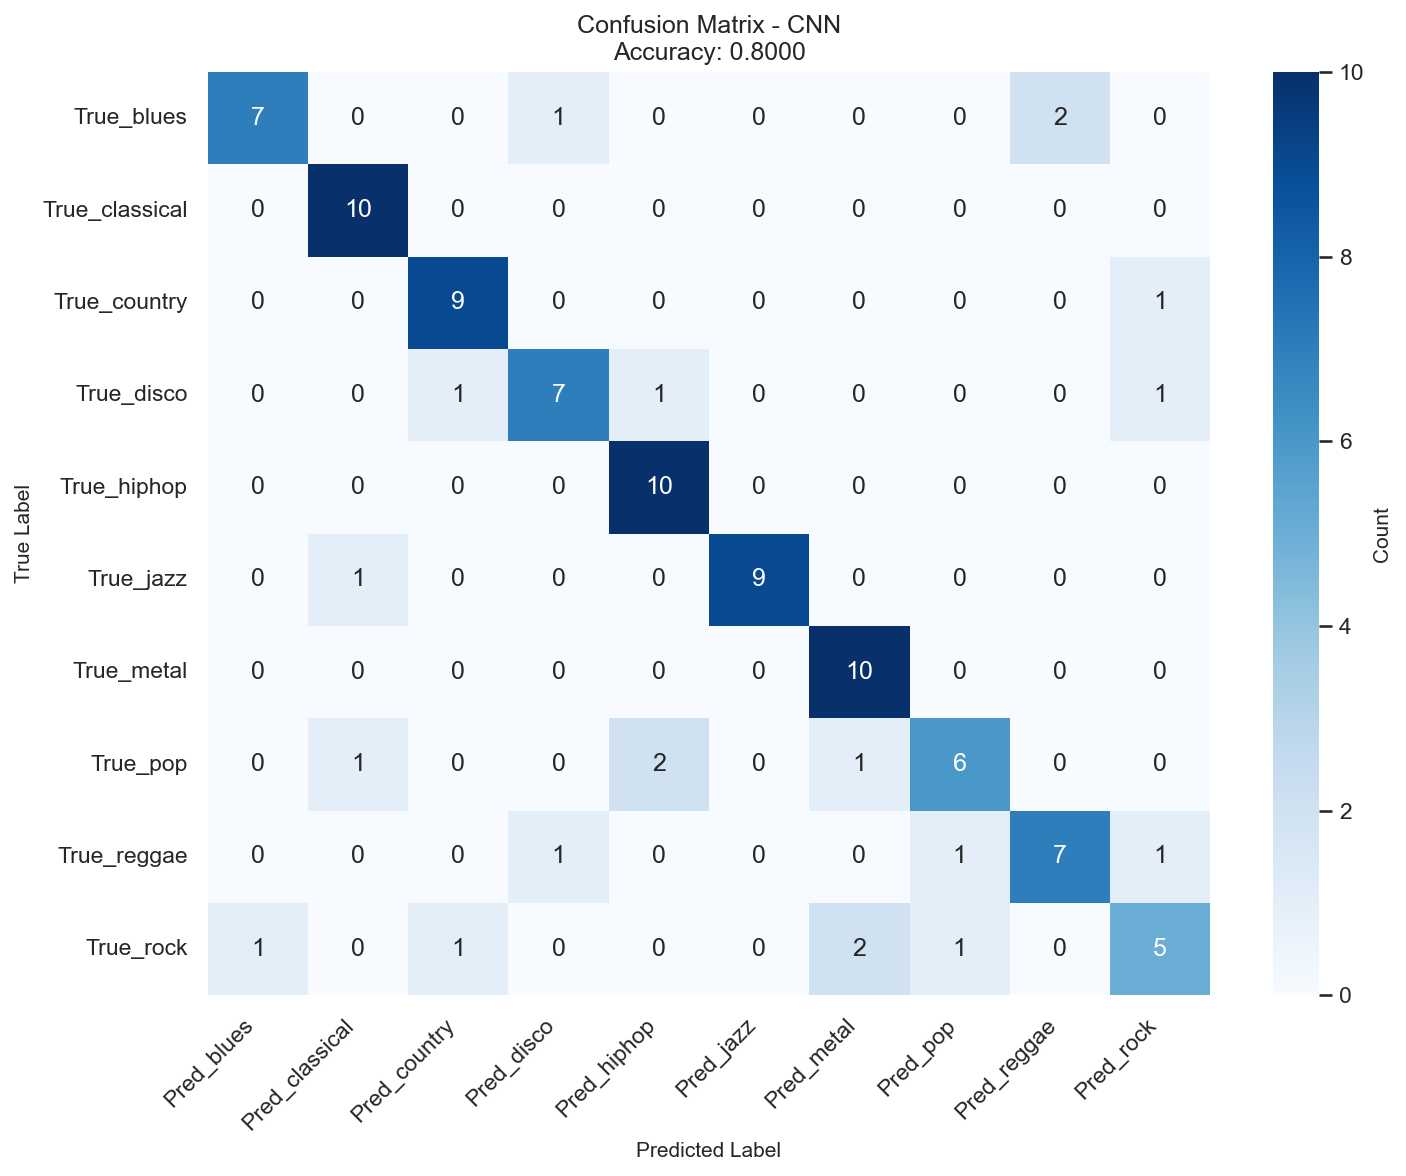

Top misclassifications:
  1. blues → reggae: 2 samples (20.0%)
  2. pop → hiphop: 2 samples (20.0%)
  3. rock → metal: 2 samples (20.0%)
  4. blues → disco: 1 samples (10.0%)
  5. country → rock: 1 samples (10.0%)


              precision    recall  f1-score   support

       blues       0.83      0.50      0.62        10
   classical       0.73      0.80      0.76        10
     country       0.88      0.70      0.78        10
       disco       0.50      0.60      0.55        10
      hiphop       0.67      0.60      0.63        10
        jazz       0.58      0.70      0.64        10
       metal       0.90      0.90      0.90        10
         pop       0.67      0.60      0.63        10
      reggae       0.50      0.50      0.50        10
        rock       0.54      0.70      0.61        10

    accuracy                           0.66       100
   macro avg       0.68      0.66      0.66       100
weighted avg       0.68      0.66      0.66       100

✓ CNN - Test Accuracy: 0.

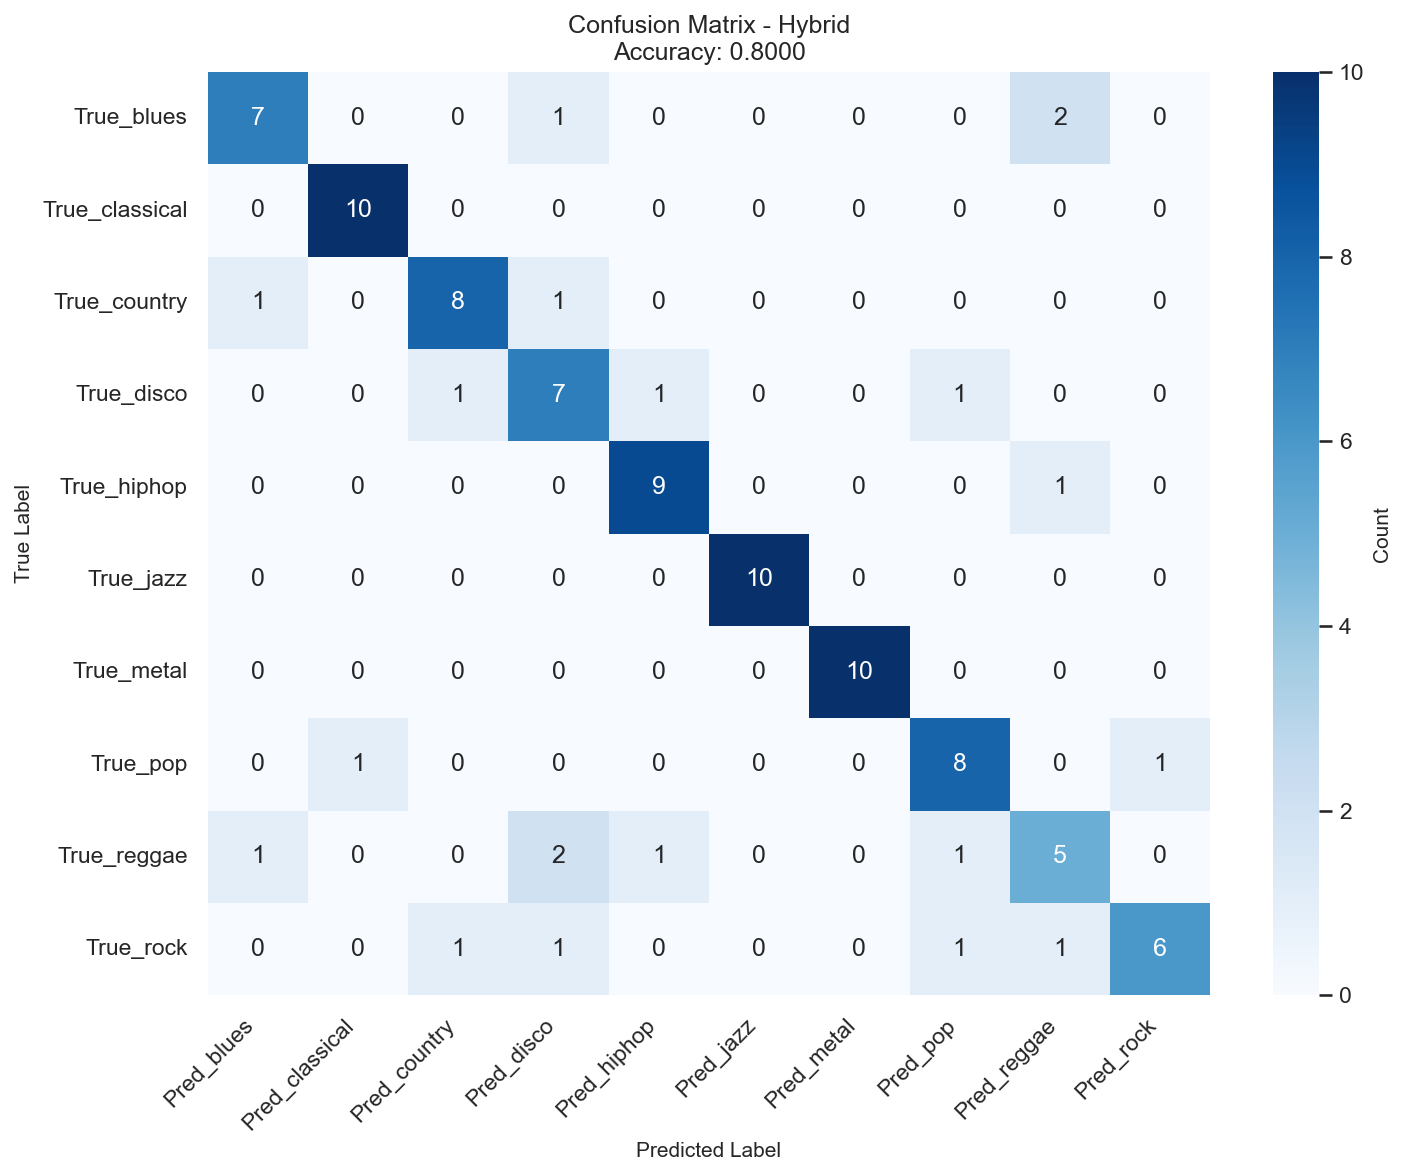

Top misclassifications:
  1. blues → reggae: 2 samples (20.0%)
  2. reggae → disco: 2 samples (20.0%)
  3. blues → disco: 1 samples (10.0%)
  4. country → blues: 1 samples (10.0%)
  5. country → disco: 1 samples (10.0%)


              precision    recall  f1-score   support

       blues       0.83      0.50      0.62        10
   classical       0.73      0.80      0.76        10
     country       0.88      0.70      0.78        10
       disco       0.50      0.60      0.55        10
      hiphop       0.67      0.60      0.63        10
        jazz       0.58      0.70      0.64        10
       metal       0.90      0.90      0.90        10
         pop       0.67      0.60      0.63        10
      reggae       0.50      0.50      0.50        10
        rock       0.54      0.70      0.61        10

    accuracy                           0.66       100
   macro avg       0.68      0.66      0.66       100
weighted avg       0.68      0.66      0.66       100

✓ Hybrid - Test Acc

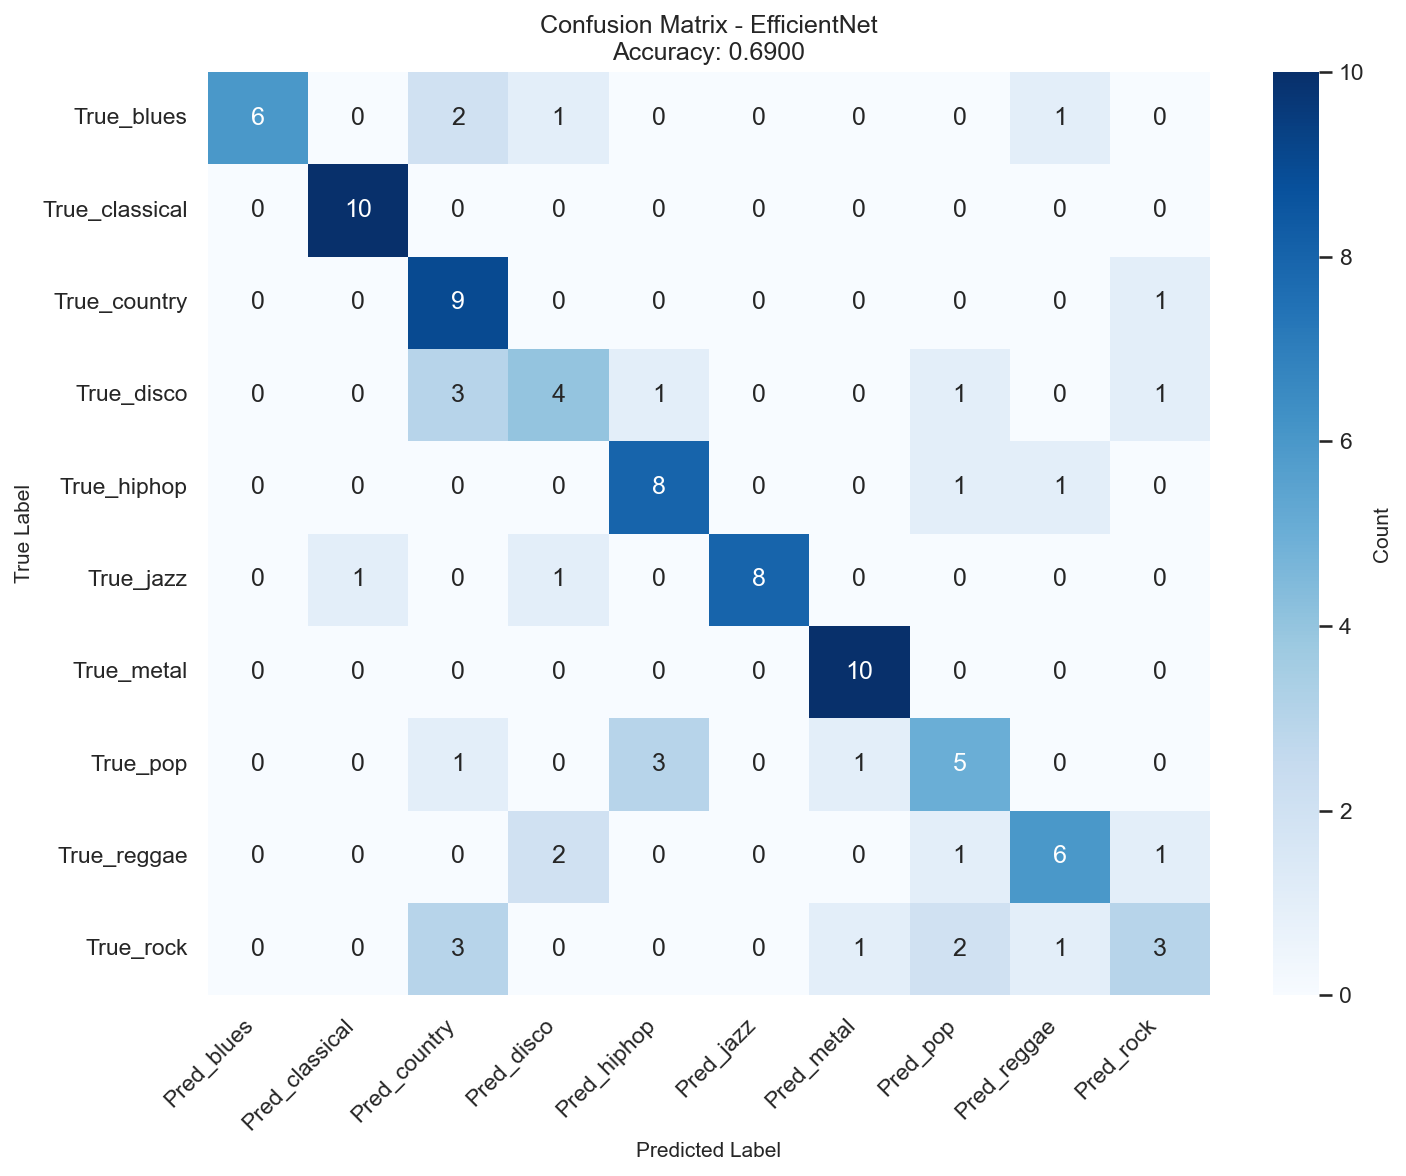

Top misclassifications:
  1. disco → country: 3 samples (30.0%)
  2. pop → hiphop: 3 samples (30.0%)
  3. rock → country: 3 samples (30.0%)
  4. blues → country: 2 samples (20.0%)
  5. reggae → disco: 2 samples (20.0%)


              precision    recall  f1-score   support

       blues       0.83      0.50      0.62        10
   classical       0.73      0.80      0.76        10
     country       0.88      0.70      0.78        10
       disco       0.50      0.60      0.55        10
      hiphop       0.67      0.60      0.63        10
        jazz       0.58      0.70      0.64        10
       metal       0.90      0.90      0.90        10
         pop       0.67      0.60      0.63        10
      reggae       0.50      0.50      0.50        10
        rock       0.54      0.70      0.61        10

    accuracy                           0.66       100
   macro avg       0.68      0.66      0.66       100
weighted avg       0.68      0.66      0.66       100

✓ EfficientNet - Tes

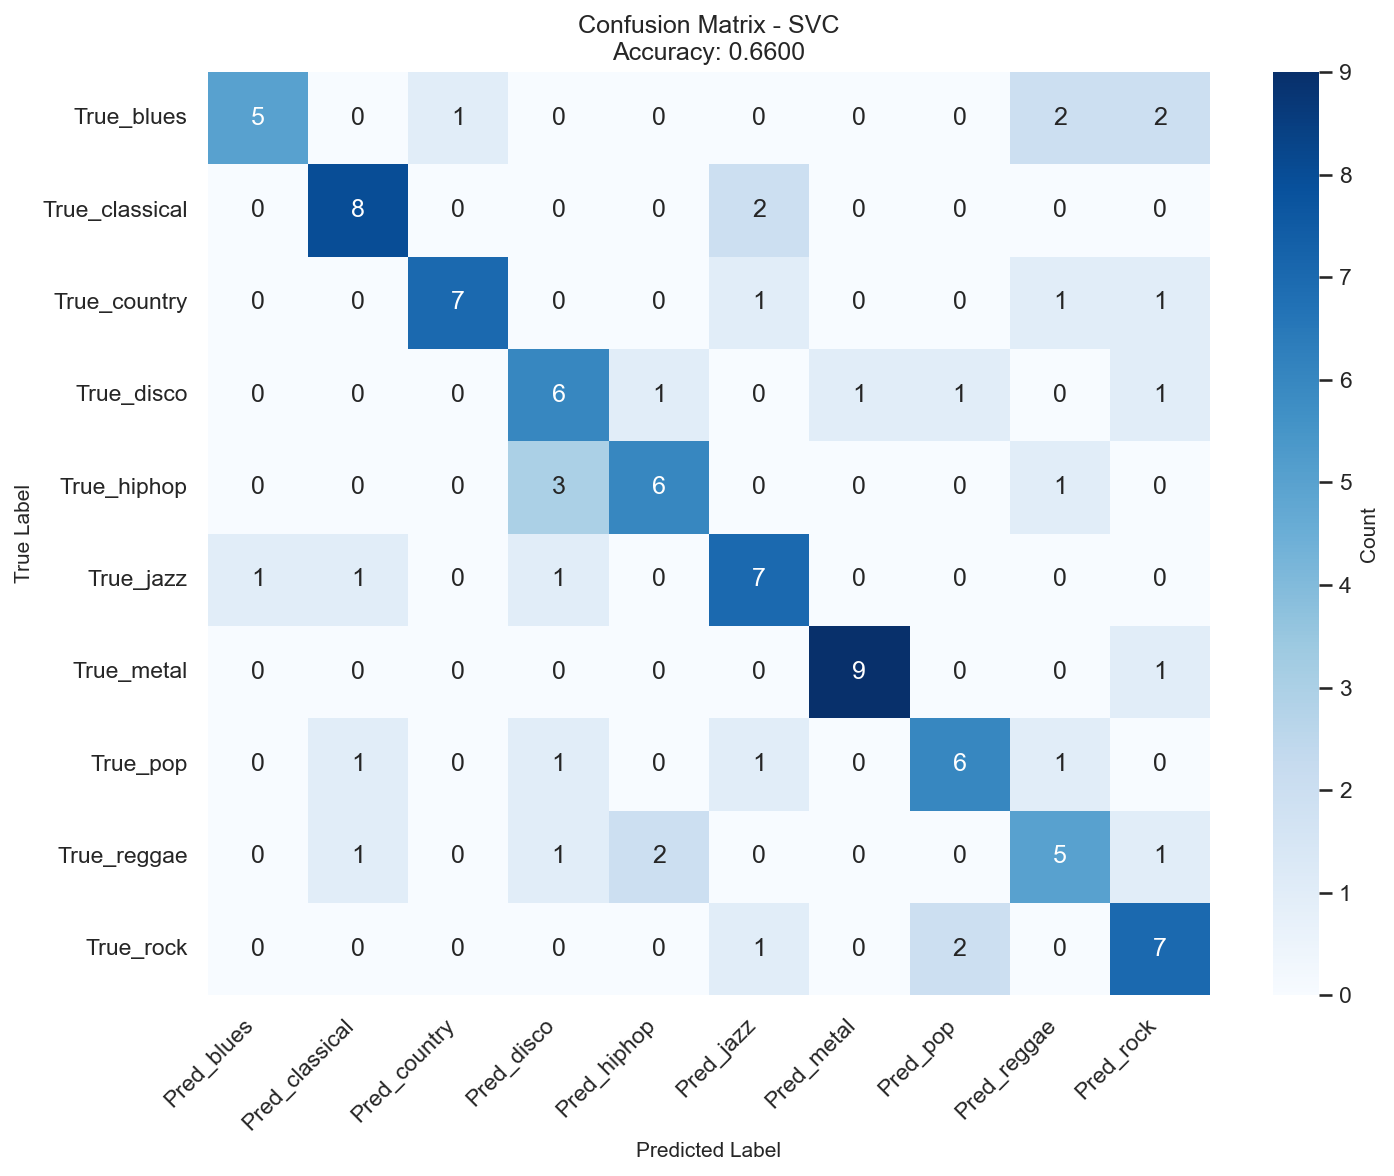

Top misclassifications:
  1. hiphop → disco: 3 samples (30.0%)
  2. blues → reggae: 2 samples (20.0%)
  3. blues → rock: 2 samples (20.0%)
  4. classical → jazz: 2 samples (20.0%)
  5. reggae → hiphop: 2 samples (20.0%)


              precision    recall  f1-score   support

       blues       0.83      0.50      0.62        10
   classical       0.73      0.80      0.76        10
     country       0.88      0.70      0.78        10
       disco       0.50      0.60      0.55        10
      hiphop       0.67      0.60      0.63        10
        jazz       0.58      0.70      0.64        10
       metal       0.90      0.90      0.90        10
         pop       0.67      0.60      0.63        10
      reggae       0.50      0.50      0.50        10
        rock       0.54      0.70      0.61        10

    accuracy                           0.66       100
   macro avg       0.68      0.66      0.66       100
weighted avg       0.68      0.66      0.66       100

✓ SVC - Test Accura

,Model,Test_Accuracy,Test_Loss,Model_Type
0,CNN,0.80,0.842999,Neural Network
1,Hybrid,0.80,0.920534,Neural Network
2,EfficientNet,0.69,1.002689,Neural Network
3,SVC,0.66,N/A,Traditional ML


In [76]:
# Function to evaluate all the models and create comparable confusion matrices and summary test results
def evaluate_test_set(models_dict, include_svc=True):
    """
    Evaluate all models on test set and generate confusion matrices for each

    Args:
        models_dict: Dictionary with trained NN models
        include_svc: Whether to include SVC in evaluation

    Returns:
        test_comparison_df: DataFrame with all model results
    """
    print("="*80)
    print("TEST SET EVALUATION - ALL MODELS")
    print("="*80)

    results = []

    # Evaluate Neural Network models
    for model_name, model_info in models_dict.items():
        print(f"\nEvaluating {model_name}...")

        model = model_info['model']
        history = model_info['history']

        # Determine dataset view and evaluate
        if 'CNN' in model_name or 'Baseline' in model_name:
            test_metrics = model.evaluate(use_image_only(test_ds), return_dict=True, verbose=0)
            # Get predictions for confusion matrix
            y_pred = model.predict(use_image_only(test_ds), verbose=0)

        elif 'Hybrid' in model_name:
            test_metrics = model.evaluate(use_hybrid(test_ds), return_dict=True, verbose=0)
            # Get predictions for confusion matrix
            y_pred = model.predict(use_hybrid(test_ds), verbose=0)

        elif 'EfficientNet' in model_name:
            test_metrics = model.evaluate(use_image_only(test_ds), return_dict=True, verbose=0)
            # Get predictions for confusion matrix
            y_pred = model.predict(use_image_only(test_ds), verbose=0)

        else:  # Features-only or unknown
            test_metrics = model.evaluate(use_features_only(test_ds), return_dict=True, verbose=0)
            # Get predictions for confusion matrix
            y_pred = model.predict(use_features_only(test_ds), verbose=0)

        # Convert probabilities to class predictions
        y_pred_classes = np.argmax(y_pred, axis=1)

        # Get true labels from test dataset
        y_true = np.concatenate([labels.numpy() for _, labels in test_ds])

        # Use your existing plot_confusion_matrix function
        cm, report = plot_cm(y_true, y_pred_classes, test_accuracy=test_metrics['acc'], model_name=model_name, class_names=CLASS_NAMES, save_plot=True)

        # Store results
        results.append({
            'Model': model_name,
            'Test_Accuracy': test_metrics['acc'],
            'Test_Loss': test_metrics['loss'],
            'Model_Type': 'Neural Network'
        })

        print(f"✓ {model_name} - Test Accuracy: {test_metrics['acc']:.4f}")

    # Add SVC if requested
    if include_svc:
        print(f"\nTraining and Evaluating SVC...")

        # Train SVC using your existing function (it already generates confusion matrix)
        svc_model, svc_metrics = train_svc_classifier(
            train_feats, train_labels,
            val_feats, val_labels,
            test_feats, test_labels,
            class_names=CLASS_NAMES
        )

        # Store SVC results
        results.append({
            'Model': 'SVC',
            'Test_Accuracy': svc_metrics['test_accuracy'],
            'Test_Loss': 'N/A',  # SVC doesn't have loss
            'Model_Type': 'Traditional ML'
        })

        print(f"✓ SVC - Test Accuracy: {svc_metrics['test_accuracy']:.4f}")

    # Create comparison DataFrame
    test_comparison_df = pd.DataFrame(results)

    # a bit ugly returning svc_metrics separately, but need it for model comparison below
    return test_comparison_df, svc_metrics


test_comparison_df, svc_metrics = evaluate_test_set(
    {
        'CNN': {'model': cnn_baseline_model, 'history': history_cnn},
        'Hybrid': {'model': hybrid_model, 'history': history_hybrid},
        'EfficientNet': {'model': efficientnet_model, 'history': history_efficientnet}
    },
    include_svc=True
)

display(test_comparison_df)
test_comparison_df.to_csv('outputs/5511_final_project/test_comparison_all_models.csv', index=False)

## 6. Results - Model Comparison

In [77]:
def model_comparison(models_dict, save_plot=True):
    """
    Simplified model comparison function that supports any number of neural network models.

    Args:
        models_dict: Dictionary with structure:
        {
            'model_name': {
                'history': training_history,
                'metrics': evaluation_metrics,
                'type': 'neural_network' or 'traditional'
            }
        }
        save_plot: Whether to save the plot
    """
    # Separate neural networks from traditional models
    nn_models = {k: v for k, v in models_dict.items() if v['type'] == 'neural_network'}
    traditional_models = {k: v for k, v in models_dict.items() if v['type'] == 'traditional'}

    # Create figure with 3 rows, 2 columns
    fig, axes = plt.subplots(3, 2, figsize=(15, 13.5))
    fig.suptitle('Model Comparison Dashboard', fontsize=16, fontweight='bold')
    colours = sns.color_palette()

    # Row 1: Training and Validation Loss
    ax1, ax2 = axes[0]
    for i, (name, model_data) in enumerate(nn_models.items()):
        hist = pd.DataFrame(model_data['history'].history)
        ax1.plot(hist['loss'], label=f'{name} Train', color=colours[i], linewidth=2)
        ax2.plot(hist['val_loss'], label=f'{name} Val', color=colours[i], linestyle='--', linewidth=2)

    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_title('Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Row 2: Training and Validation Accuracy
    ax3, ax4 = axes[1]
    for i, (name, model_data) in enumerate(nn_models.items()):
        hist = pd.DataFrame(model_data['history'].history)
        ax3.plot(hist['acc'], label=f'{name} Train', color=colours[i], linewidth=2)
        ax4.plot(hist['val_acc'], label=f'{name} Val', color=colours[i], linestyle='--', linewidth=2)

    ax3.set_title('Training Accuracy')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    ax4.set_title('Validation Accuracy')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Row 3: Test Accuracy Comparison (All Models)
    ax5 = axes[2, 0]
    model_names = list(models_dict.keys())
    test_accuracies = []

    for name, model_data in models_dict.items():
        if model_data['type'] == 'neural_network':
            test_accuracies.append(model_data['metrics']['acc'])
        else:  # traditional model
            test_accuracies.append(model_data['metrics']['test_accuracy'])

    bars = ax5.bar(model_names, test_accuracies, color=colours[:len(model_names)],
                   alpha=0.7, edgecolor='black')
    ax5.set_title('Test Accuracy Comparison')
    ax5.set_ylabel('Test Accuracy')
    ax5.set_ylim(0, 1)
    ax5.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar, acc in zip(bars, test_accuracies):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')

    # Hide the last subplot
    axes[2, 1].set_visible(False)

    plt.tight_layout()

    if save_plot:
        save_figure('model_comparison')

    plt.show()

    # Print summary
    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)

    results = []
    for name, model_data in models_dict.items():
        if model_data['type'] == 'neural_network':
            hist = pd.DataFrame(model_data['history'].history)

            # Calculate gaps
            final_train_acc = hist['acc'].iloc[-1]
            final_val_acc = hist['val_acc'].iloc[-1]
            test_acc = model_data['metrics']['acc']
            best_val_acc = hist['val_acc'].max()

            # Overfitting gap: difference between training and validation performance
            overfitting_gap = final_train_acc - final_val_acc

            # Generalization gap: difference between validation and test performance
            generalization_gap = final_val_acc - test_acc

            results.append({
                'Model': name,
                'Final_Train_Acc': final_train_acc,
                'Final_Val_Acc': final_val_acc,
                'Test_Accuracy': test_acc,
                'Best_Val_Acc': best_val_acc,
                'Overfitting_Gap': overfitting_gap,
                'Generalization_Gap': generalization_gap,
                'Final_Train_Loss': hist['loss'].iloc[-1],
                'Final_Val_Loss': hist['val_loss'].iloc[-1]
            })
        else:  # traditional model
            train_acc = model_data['metrics']['train_accuracy']
            val_acc = model_data['metrics']['val_accuracy']
            test_acc = model_data['metrics']['test_accuracy']
            results.append({
                'Model': name,
                'Final_Train_Acc': train_acc,
                'Final_Val_Acc': val_acc,
                'Test_Accuracy': test_acc,
                'Best_Val_Acc': 'N/A',
                'Overfitting_Gap': 'N/A', # not meaningful for traditional models
                'Generalization_Gap': val_acc - test_acc,
                'Final_Train_Loss': 'N/A',
                'Final_Val_Loss': 'N/A'
            })

    results_df = pd.DataFrame(results)

    # Format numerical columns for better display
    numeric_cols = ['Final_Train_Acc', 'Final_Val_Acc', 'Test_Accuracy', 'Best_Val_Acc',
                   'Overfitting_Gap', 'Generalization_Gap', 'Final_Train_Loss', 'Final_Val_Loss']

    display_df = results_df.copy()
    for col in numeric_cols:
        if col in display_df.columns:
            # Only format numeric values, leave 'N/A' as is
            display_df[col] = display_df[col].apply(
                lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
            )

    print(display_df.to_string(index=False))
    # Additional interpretation
    print("\n" + "="*80)
    print("GAP INTERPRETATION")
    print("="*80)

    for _, row in results_df.iterrows():
        if row['Overfitting_Gap'] == 'N/A':
            print(f"\n{row['Model']}:")
            print(f"  ℹ️  Traditional ML model - overfitting gap not applicable")
            if isinstance(row['Generalization_Gap'], (int, float)):
                if row['Generalization_Gap'] > 0.05:
                    print(f"  🔴 Poor generalization (gap: {row['Generalization_Gap']:.3f})")
                else:
                    print(f"  🟢 Good generalization (gap: {row['Generalization_Gap']:.3f})")

        elif row['Model'] != 'N/A' and isinstance(row['Overfitting_Gap'], (int, float)):
            print(f"\n{row['Model']}:")
            # Overfitting gap interpretation
            if row['Overfitting_Gap'] > 0.05:
                print(f"  🔴 High overfitting (gap: {row['Overfitting_Gap']:.3f}) - model memorizes training data")
            elif row['Overfitting_Gap'] > 0.02:
                print(f"  🟡 Moderate overfitting (gap: {row['Overfitting_Gap']:.3f}) - some memorization")
            else:
                print(f"  🟢 Low overfitting (gap: {row['Overfitting_Gap']:.3f}) - good generalization to validation")
            # Generalization gap interpretation
            if row['Generalization_Gap'] > 0.05:
                print(f"  🔴 Poor generalization (gap: {row['Generalization_Gap']:.3f}) - validation doesn't predict test well")
            elif row['Generalization_Gap'] > 0.02:
                print(f"  🟡 Moderate generalization (gap: {row['Generalization_Gap']:.3f}) - some domain shift")
            elif row['Generalization_Gap'] < -0.02:
                print(f"  🟡 Test better than validation (gap: {row['Generalization_Gap']:.3f}) - possible data leak or lucky split")
            else:
                print(f"  🟢 Good generalization (gap: {row['Generalization_Gap']:.3f}) - consistent performance")

    return results_df


Figure saved: figs/5511_final_project/model_comparison.png


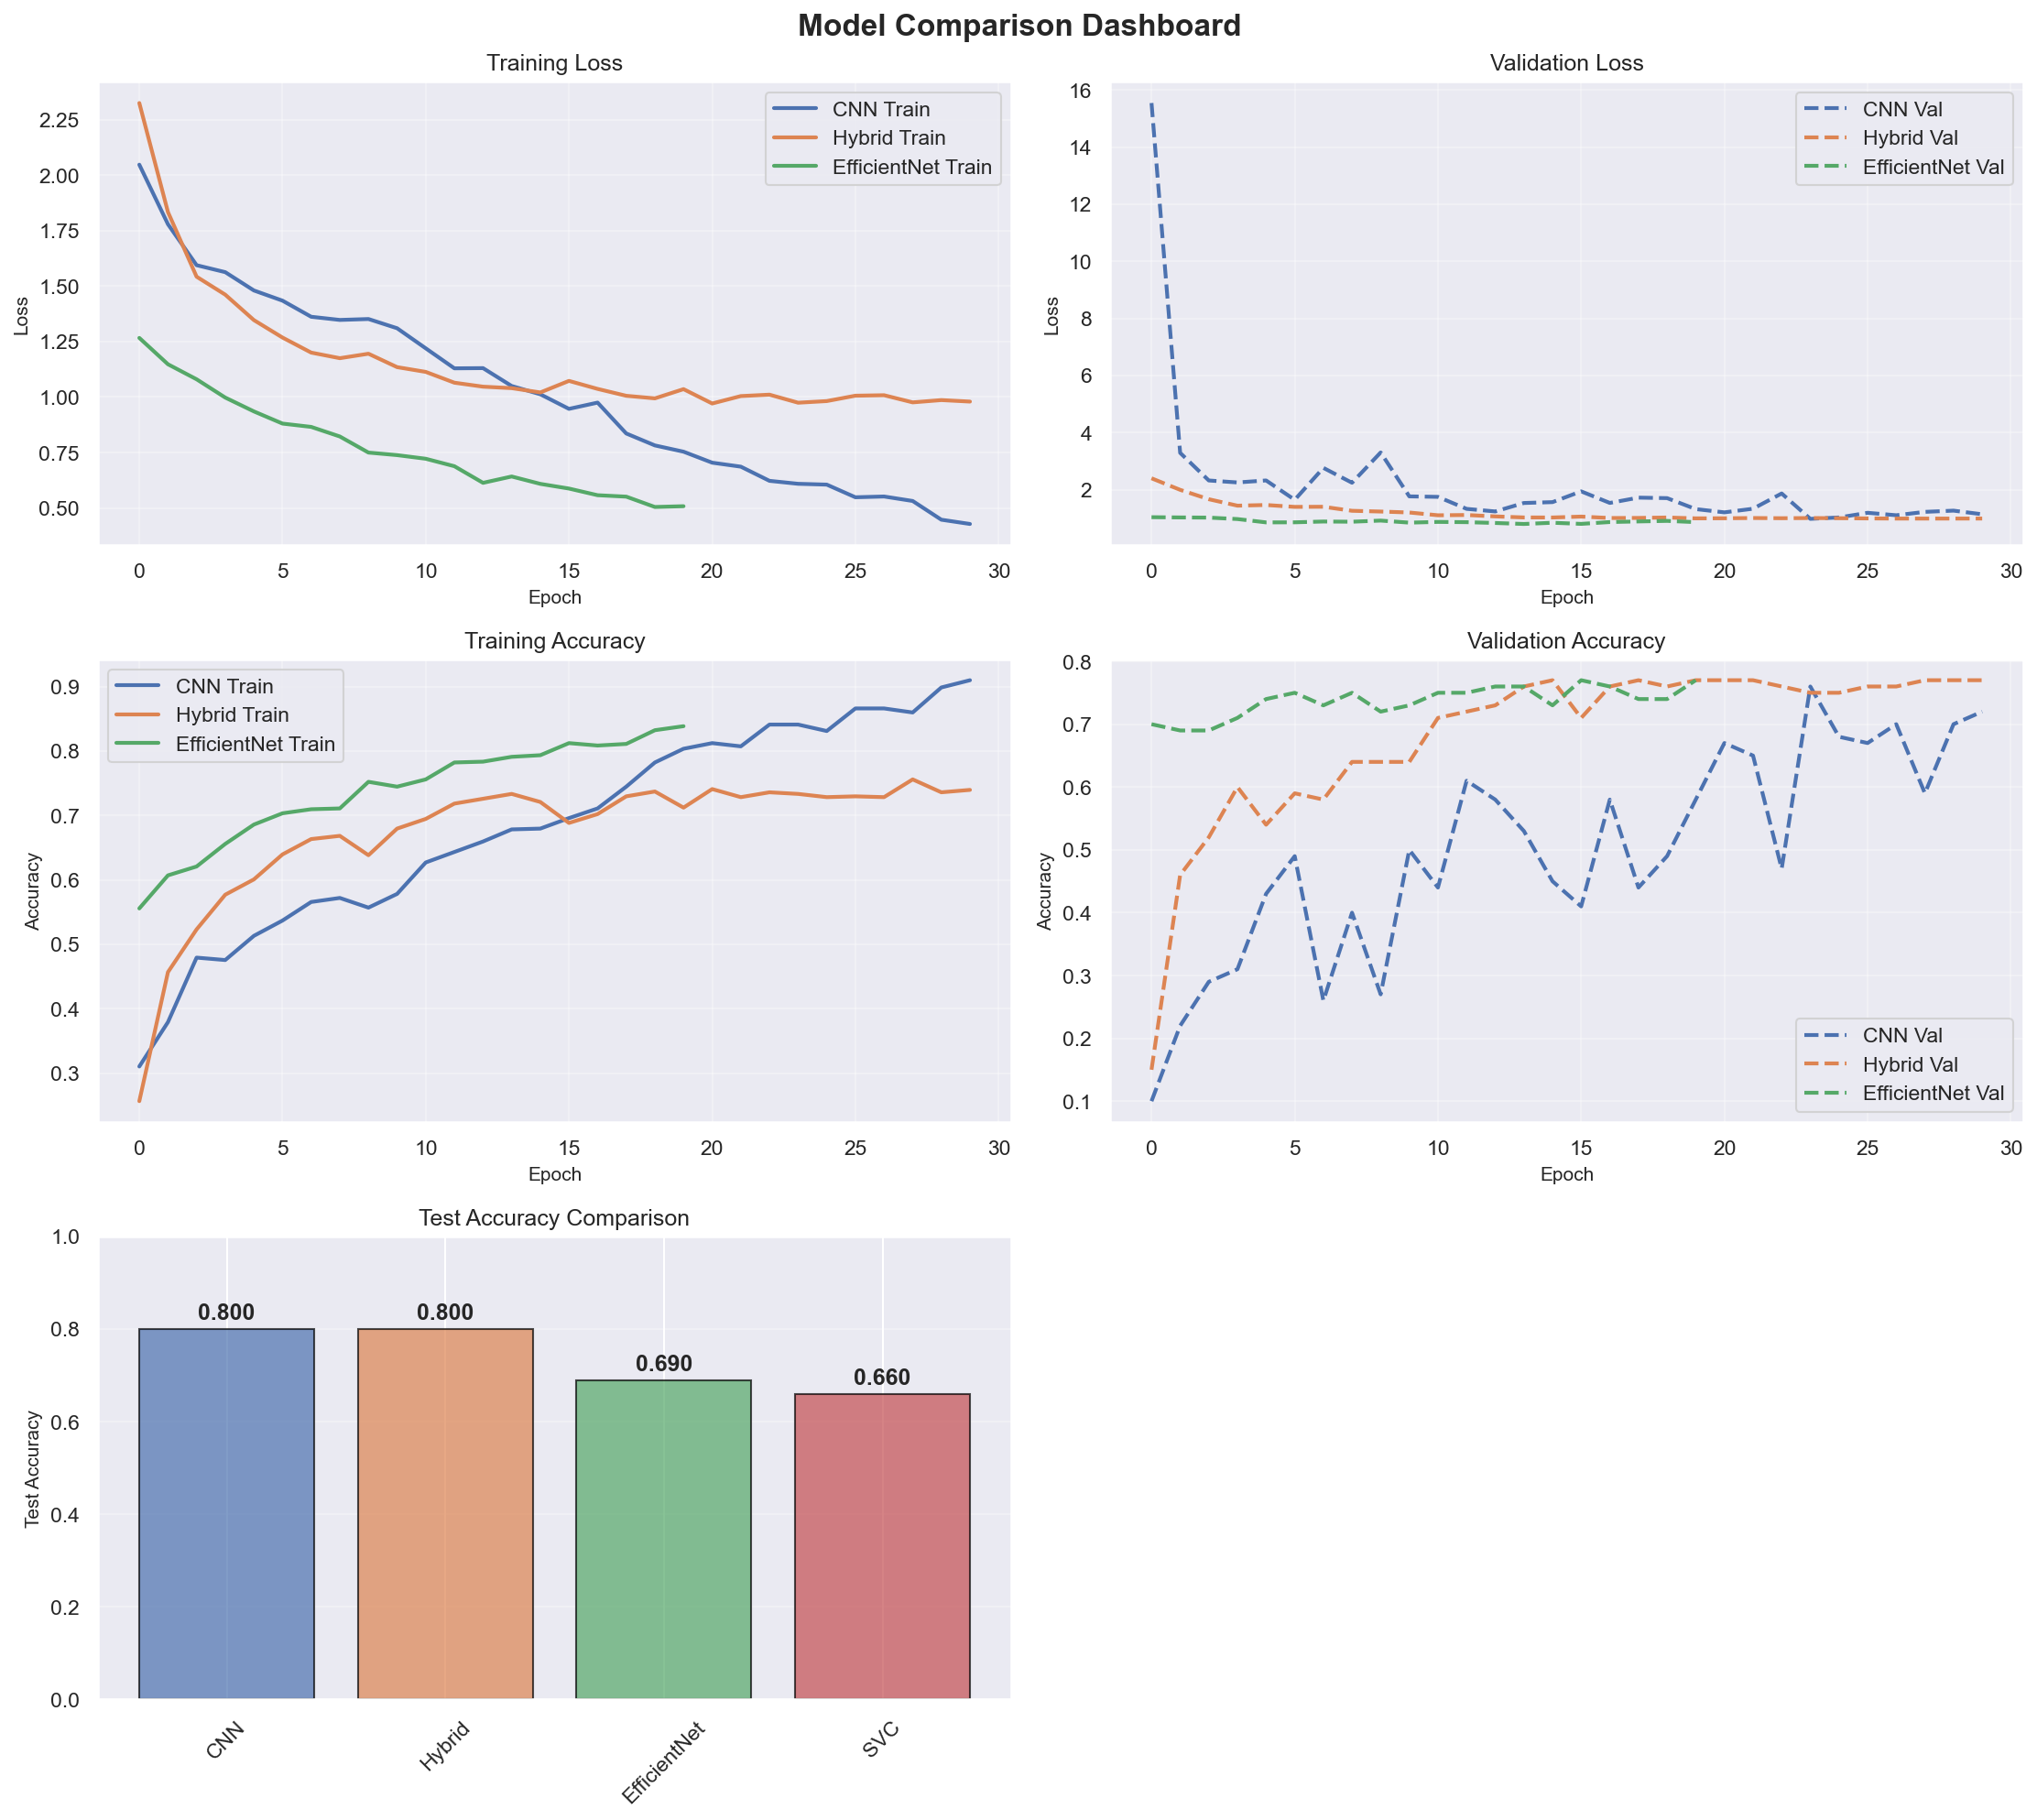


MODEL COMPARISON SUMMARY
       Model Final_Train_Acc Final_Val_Acc Test_Accuracy Best_Val_Acc Overfitting_Gap Generalization_Gap Final_Train_Loss Final_Val_Loss
         CNN          0.9099        0.7200        0.8000       0.7600          0.1899            -0.0800           0.4282         1.1356
      Hybrid          0.7397        0.7700        0.8000       0.7700         -0.0303            -0.0300           0.9795         0.9861
EfficientNet          0.8385        0.7700        0.6900       0.7700          0.0685             0.0800           0.5082         0.8603
         SVC          0.9812        0.7500        0.6600          N/A             N/A             0.0900              N/A            N/A

GAP INTERPRETATION

CNN:
  🔴 High overfitting (gap: 0.190) - model memorizes training data
  🟡 Test better than validation (gap: -0.080) - possible data leak or lucky split

Hybrid:
  🟢 Low overfitting (gap: -0.030) - good generalization to validation
  🟡 Test better than validation (gap

In [78]:
models = {
    'CNN': {
        'history': history_cnn,
        'metrics': metrics_cnn,
        'type': 'neural_network'
    },
    'Hybrid': {
        'history': history_hybrid,
        'metrics': metrics_hybrid,
        'type': 'neural_network'
    },
    'EfficientNet': {
        'history': history_efficientnet,
        'metrics': metrics_efficientnet,
        'type': 'neural_network'
    },
    'SVC': {
        'history': None,
        'metrics': svc_metrics,
        'type': 'traditional'
    }

}

results_df = model_comparison(models)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_df.to_csv(OUTPUT_DIR / f'model_comparison_{timestamp}.csv', index=False)


## 9. Discussion & Conclusion

#### Results Summary
There is less of a difference than I would have expected between the CNN, Hybrid, and EfficientNet models. Also, given that there are vague boundaries and overlaps between genres of music, it is unsurprising that we don't reach a perfect score. 80% seems reasonable. The exact match in the figures shown in the Model Comparison which appears suspicious, is coincidence. This can be verified by checking the confusion matrices, which show different genres are confused by each model. Also, when running with differing parameters, the models deliver different results.

However, the results are highly sensitive to the choice of parameters, In particular the Hybrid model had test accuracy varying between 0.12 and 0.81, with roughly the same validation accuracy in both cases. This is quite odd, and suggests issues in pre-processing. However, the other models did not see the same swings in performance and they are reliant on the same pre-processing pipeline. Unless there is specific bug in using the dataset with both features and images, I am at a loss to explain why this happened.

Beyond this specific Hybrid issue: some of the variation in results may be explained by the small dataset size: different random splits may be having some impact even though I made an attempt to use stratified splits. This may also explain why we have models that perform better on the test set than on the valideation set.

Here is a summary of conclusions about the metrics:

| Model      | Train Acc | Val Acc | Test Acc | Notes                                                                                                 |
|------------|-----------|---------|----------|-------------------------------------------------------------------------------------------------------|
| **CNN**    | 0.91      | 0.72    | 0.80     | Overfits (big train–val gap), but test > val suggests validation set may not be fully representative. |
| **Hybrid** | 0.74      | 0.77    | 0.80     | More balanced — training weaker, but generalizes well. Underfitting a bit, but stable.                |
| **EffNet** | 0.84      | 0.77    | 0.69     | Validation looked good, but test dropped → possible overfitting to val, or sensitivity to split.      |
| **SVC**    | 0.98      | 0.75    | 0.66     | Almost perfect on training (classic overfit), poor generalization to val/test.                        |


**Conclusion:** The CNN model is overfitting, and the Hybrid model is performing better than the EfficientNet model.

#### Challenges and Lessons Learned
At this stage in my learning journey, the majority of challenges faced concern process and personal knowledge level.
- The one that caused me the most time and effort: tracking changes in an easily reversible manner across training runs and results observations. For example: I have a saved version of the results where the Hybrid model has a test-accuracy of 0.8, but I have not been able to repeat that result. This seems non-trivial to me, as it runs against the linear nature of the Jupyter notebook, once you start iterating it is too easy to lose the thread. **ACTION:** Plan the database to capture the experiment settings before heading into modelling. Make sure it is possible to change parameters in pre-processing, model definition and training and store those changes into the database prior to commencing a new run. This likely means defining CLasses to handle the models and experiments - such that it is easier to retain parameters with them.
- Impact of hyperparameters. This is definitely part of the art of working with deep-learning. But, I am struggling with two aspects: (1) the unpredictability of the impact, (2) the delay between changing a parameter and seeing the result, training can take hours.

Then for this specific project, the small size of the dataset meant that over-fitting was happening too often and it proved hard to cure.


#### Future Work

Clearly, addressing the challenges mentioned above is key for my personal journey.

With regards to this specific project task it would be interesting to:
- Use the output of the EfficientNet as part of a hybrid model, to see if that can improve accuracy.
- Check to see whether the 3-sec version of the feature extraction can be used to improve accuracy.
- Tune hyper-parameters
- Spend more time reviewing what others have done to see how to improve both process and results.


## 10. Citations

1) Fiona for approach to feature extraction (alternative to image classification): https://www.kaggle.com/code/fionadang426/fiona-music-genre-classification
2) Kaggle for the GTZAN dataset: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/data